# Falcon 9 / BCHH Figure Generation Notebook

This notebook generates the overview, zoom, timing-diagnostic, and spectral figures for the 1 September 2016 Falcon 9 static-fire anomaly.

The workflow is organized so that:

- source-time picks and processing assumptions are explicit;
- launch-pad and camera coordinates come from KML;
- BCHH channel coordinates come from time-selected StationXML;
- source-to-receiver distances, ray azimuths, acoustic speeds, and travel times are calculated rather than hardcoded;
- causal and zero-phase filtering can be compared without changing function internals.


## Transitional notebook status

This notebook currently generates Figures 2 onward. It can be split into one notebook per figure later, once the final figure list and numbering stabilize. Shared metadata and physics code already live in reusable modules.


# NOTE: explicit-parameter and zero-phase comparison version

Reusable functions receive their processing choices explicitly. The notebook can generate matched outputs using both causal (`zerophase=False`) and acausal (`zerophase=True`) filtering.

Spatial metadata and acoustic propagation are also receiver-specific: each camera and BCHH channel uses its own distance and ray azimuth.


In [1]:
from pathlib import Path
import sys

# Resolve the project root whether the notebook is run from the project root
# or from the notebooks directory.
CURRENT_DIR = Path.cwd().resolve().parent
PROJECT_ROOT = (
    CURRENT_DIR.parent
    if CURRENT_DIR.name == "notebooks"
    else CURRENT_DIR
)

MODULE_DIR = PROJECT_ROOT / "modules"
if str(MODULE_DIR) not in sys.path:
    sys.path.insert(0, str(MODULE_DIR))

import warnings
from pprint import pprint

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from obspy import Stream, Trace, UTCDateTime, read, read_inventory
from pyproj import Geod

from kml_utils import read_kml_points
from xml_utils import inventory_channels_to_dataframe

plt.rcParams.update(
    {
        "font.size": 9,
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "figure.dpi": 120,
    }
)


## 2. Configuration and event metadata

This section contains the notebook-specific paths, source-time picks, environmental assumptions, and metadata selections.

Spatial information is not hardcoded:

- launch-pad and camera positions are read from KML;
- BCHH channel positions are read from the StationXML epoch active on 1 September 2016;
- source-to-receiver distances and ray azimuths are computed geodetically.

The StationXML component orientation (`azimuth_deg`) is kept separate from the propagation direction (`ray_azimuth_deg`).

In [2]:
# -----------------------------------------------------------------------------
# Paths
# -----------------------------------------------------------------------------
OUTDIR = PROJECT_ROOT / "outputs" / "main"
OUTDIR.mkdir(parents=True, exist_ok=True)

# Authoritative products created by 01_correct_bchh_instrument_response_final.ipynb.
RESPONSE_PRODUCT_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "response_correction"
    / "final_products"
)

CORRECTED_PICKLE_FILE = (
    RESPONSE_PRODUCT_DIR
    / "BCHH_20160901_response_corrected.pkl"
)
CORRECTED_MSEED_FILE = (
    RESPONSE_PRODUCT_DIR
    / "BCHH_20160901_response_corrected.mseed"
)
CORRECTED_STATIONXML_FILE = (
    RESPONSE_PRODUCT_DIR
    / "BCHH_20160901_empirically_calibrated.xml"
)
CORRECTION_SUMMARY_FILE = (
    RESPONSE_PRODUCT_DIR
    / "BCHH_20160901_correction_summary.csv"
)

AUDIO_FILE = Path(
    "/Users/thompsong/Library/CloudStorage/Box-Box/"
    "thompsong/3_Project_Documents/NASAprojects/"
    "201602_Rocket_Seismology/02_KSC/spaceX_explosion_movie/"
    "syncedsound2.mp3"
)

KML_FILE = PROJECT_ROOT / "metadata" / "launchpads_cameras.kml"

CHANNEL_ORDER = ["HD1", "HD2", "HD3", "HHE", "HHN", "HHZ"]

# Metadata epoch and station selection.
EVENT_START = UTCDateTime("2016-09-01T00:00:00")
EVENT_END = UTCDateTime("2016-09-02T00:00:00")

BCHH_NETWORK = "1R"
BCHH_STATION = "BCHH"
BCHH_LOCATION = "10"

# Filtering: causal or acausal.
ZEROPHASE = False
RUN_ZEROPHASE_COMPARISON = True
ZEROPHASE_RUNS = [False, True]


### 2.1 Video-derived source times

The event times below are the current working picks derived from the video sequence. They are defined only once here; the previous duplicate frame-based and hardcoded definitions have been removed.

`utc_from_hms_frame` remains available for revising a pick directly from a frame number.

In [3]:
FPS = 30.0
EVENT_DATE = "2016-09-01"


def utc_from_hms_frame(hh, mm, ss, frame, fps, date):
    """Convert HH:MM:SS plus a possibly fractional frame to UTC."""
    base = UTCDateTime(f"{date}T{hh:02d}:{mm:02d}:{ss:02d}")
    return base + float(frame) / float(fps)


# Current working source-time picks.
EXPLOSION_TIME = UTCDateTime("2016-09-01T13:07:12.080")
precursor1 = UTCDateTime("2016-09-01T13:07:15.283")
precursor2 = UTCDateTime("2016-09-01T13:07:15.517")
FIRST_STAGE = UTCDateTime("2016-09-01T13:07:15.750")
CAPSULE = UTCDateTime("2016-09-01T13:07:24.600")

SOURCE_EVENTS = {
    "Second\nstage": EXPLOSION_TIME,
    "precursor1": precursor1,
    "precursor2": precursor2,
    "First\nstage": FIRST_STAGE,
    "Capsule": CAPSULE,
}

VIDEO_PICK_UNCERTAINTY_S = 1.0 / FPS

# Overview window and phase annotations.
PRE_EVENT_SEC = 180
POST_EVENT_SEC = 1800
PLOT_START = EXPLOSION_TIME - 150
PLOT_END = EXPLOSION_TIME + POST_EVENT_SEC

PHASES = [
    ("Phase I", EXPLOSION_TIME, EXPLOSION_TIME + 70),
    (
        "Phase II",
        UTCDateTime("2016-09-01T13:14:15"),
        UTCDateTime("2016-09-01T13:15:45"),
    ),
    (
        "Phase III",
        UTCDateTime("2016-09-01T13:19:12"),
        UTCDateTime("2016-09-01T13:25:00"),
    ),
    (
        "Phase IV",
        UTCDateTime("2016-09-01T13:29:54"),
        UTCDateTime("2016-09-01T13:34:54"),
    ),
]

TREMOR_START = UTCDateTime("2016-09-01T13:08:48")
TREMOR_END = UTCDateTime("2016-09-01T13:12:00")


### 2.2 Atmospheric assumptions

These values are passed to the acoustic propagation calculation for every camera and every BCHH channel. Each receiver uses its own source-to-receiver distance and ray azimuth.

In [4]:
RelativeHumidityPercent = 89.5
TemperatureF = 80.65
WindDirectionFromDeg = 144.0
WindSpeedKnots = 5.5
REFERENCE_OVERPRESSURE_PA = 1400.0

# Convenience values for reporting only.
WindDirectionToDeg = (WindDirectionFromDeg + 180.0) % 360.0
WindSpeedMps = WindSpeedKnots * 0.514444


### 2.3 Load camera, launch-pad, and BCHH channel geometry

The KML placemark names are mapped onto the shorter identifiers used by this notebook. StationXML channel names are mapped onto the waveform channel names found in the MiniSEED files.

Two different azimuth concepts are retained:

- `azimuth_deg`: component orientation from StationXML;
- `ray_azimuth_deg`: propagation bearing from SLC-40 to the receiver.

Only `ray_azimuth_deg` is used for wind projection and acoustic travel-time calculations.

In [5]:
GEOD = Geod(ellps="WGS84")


def source_geometry(source, receiver, geod):
    """Return geodesic distance and forward source-to-receiver azimuth."""
    ray_azimuth_deg, _, distance_m = geod.inv(
        float(source["lon"]),
        float(source["lat"]),
        float(receiver["lon"]),
        float(receiver["lat"]),
    )
    return float(distance_m), float(ray_azimuth_deg % 360.0)


def calculate_row_geometry(row, source, geod):
    """Calculate source-to-receiver geometry for one DataFrame row."""
    receiver = {
        "lon": float(row["longitude"]),
        "lat": float(row["latitude"]),
    }
    distance_m, ray_azimuth_deg = source_geometry(
        source=source,
        receiver=receiver,
        geod=geod,
    )
    return pd.Series(
        {
            "distance_m": distance_m,
            "ray_azimuth_deg": ray_azimuth_deg,
        }
    )


# Fixed infrastructure and cameras from KML.
kml_locations = read_kml_points(KML_FILE)
SLC40 = kml_locations["SLC40"]
SLC41 = kml_locations["SLC41"]

CAMERA_KML_NAMES = {
    "youtube": "YouTube Video",
    "pad_nw": "Pad NW",
    "pad_west": "Pad West",
    "pad_ne": "NE Tower",
    "ucs3": "UCS-3",
}

CAMERA_DISPLAY_NAMES = {
    "youtube": "FIREY",
    "pad_nw": "PadNW",
    "pad_west": "PadW",
    "pad_ne": "PadNE",
    "ucs3": "UCS-3",
}

camera_rows = []

for camera_id, kml_name in CAMERA_KML_NAMES.items():
    point = kml_locations[kml_name]
    distance_m, ray_azimuth_deg = source_geometry(
        source=SLC40,
        receiver=point,
        geod=GEOD,
    )

    camera_rows.append(
        {
            "camera_id": camera_id,
            "name": CAMERA_DISPLAY_NAMES[camera_id],
            "latitude": float(point["lat"]),
            "longitude": float(point["lon"]),
            "altitude_m": point.get("altitude_m"),
            "distance_m": distance_m,
            "ray_azimuth_deg": ray_azimuth_deg,
            "coordinate_source": f"KML placemark: {kml_name}",
        }
    )

camera_locations_df = pd.DataFrame(camera_rows)

# Authoritative empirically calibrated BCHH inventory produced by notebook 01.
if not CORRECTED_STATIONXML_FILE.exists():
    raise FileNotFoundError(
        "Corrected StationXML not found. Run "
        "01_correct_bchh_instrument_response_final.ipynb first:\n"
        f"  {CORRECTED_STATIONXML_FILE}"
    )

inventory_event = read_inventory(str(CORRECTED_STATIONXML_FILE)).select(
    network=BCHH_NETWORK,
    station=BCHH_STATION,
    location=BCHH_LOCATION,
    starttime=EVENT_START,
    endtime=EVENT_END,
)

channels_df = inventory_channels_to_dataframe(inventory_event)

bchh_channels_df = channels_df.loc[
    (channels_df["network"] == BCHH_NETWORK)
    & (channels_df["station"] == BCHH_STATION)
    & (channels_df["location"] == BCHH_LOCATION)
].copy()

XML_TO_WAVEFORM_CHANNEL = {
    "DHE": "HHE",
    "DHN": "HHN",
    "DHZ": "HHZ",
    "DD1": "HD1",
    "DD2": "HD2",
    "DD3": "HD3",
}

bchh_channels_df = bchh_channels_df.loc[
    bchh_channels_df["channel"].isin(XML_TO_WAVEFORM_CHANNEL)
].copy()

bchh_channels_df["waveform_channel"] = (
    bchh_channels_df["channel"].map(XML_TO_WAVEFORM_CHANNEL)
)

geometry_df = bchh_channels_df.apply(
    calculate_row_geometry,
    axis=1,
    source=SLC40,
    geod=GEOD,
)

bchh_channels_df = pd.concat(
    [
        bchh_channels_df.reset_index(drop=True),
        geometry_df.reset_index(drop=True),
    ],
    axis=1,
)

display(
    camera_locations_df[
        [
            "camera_id",
            "name",
            "latitude",
            "longitude",
            "distance_m",
            "ray_azimuth_deg",
        ]
    ]
)

display(
    bchh_channels_df[
        [
            "seed_id",
            "channel",
            "waveform_channel",
            "latitude",
            "longitude",
            "distance_m",
            "azimuth_deg",
            "ray_azimuth_deg",
        ]
    ]
)


,camera_id,name,latitude,longitude,distance_m,ray_azimuth_deg
0,youtube,FIREY,28.551140,-80.618930,4254.532067,253.676701
1,pad_nw,PadNW,28.562646,-80.577882,102.864227,319.923729
2,pad_west,PadW,28.562160,-80.578559,134.745638,280.624512
3,pad_ne,PadNE,28.562393,-80.576702,70.670423,44.172628
4,ucs3,UCS-3,28.575108,-80.573638,1501.050255,13.445065


,seed_id,channel,waveform_channel,latitude,longitude,distance_m,azimuth_deg,ray_azimuth_deg
0,1R.BCHH.10.DD1,DD1,HD1,28.574222,-80.572417,1439.963831,0.0,18.985737
1,1R.BCHH.10.DD2,DD2,HD2,28.573881,-80.572296,1408.338457,90.0,19.940904
2,1R.BCHH.10.DD3,DD3,HD3,28.574006,-80.572560,1412.854330,0.0,18.761692
3,1R.BCHH.10.DHE,DHE,HHE,28.574017,-80.572376,1419.886511,90.0,19.435717
4,1R.BCHH.10.DHN,DHN,HHN,28.574017,-80.572376,1419.886511,0.0,19.435717
5,1R.BCHH.10.DHZ,DHZ,HHZ,28.574017,-80.572376,1419.886511,0.0,19.435717


## 3. Receiver-specific acoustic propagation

The acoustic calculation is run independently for each camera and each BCHH channel. This prevents component orientation from being mistaken for propagation azimuth and allows the small distance and bearing differences across the array to be retained.

The output tables include:

- still-air sound speed;
- wind component along the ray;
- acoustic speed including wind but excluding shock enhancement;
- shock-enhanced effective speed;
- ordinary acoustic and shock-enhanced travel times.

In [6]:
from physics import (
    compute_speed_of_sound,
    effective_sound_speed_along_ray,
    fahrenheit_to_celsius,
    mach_vs_overpressure,
)

print("Using physics functions from local physics.py")


def add_acoustic_propagation_columns(
    dataframe,
    *,
    temperature_f,
    relative_humidity_percent,
    wind_direction_from_deg,
    wind_speed_knots,
    reference_overpressure_pa,
    distance_column="distance_m",
    azimuth_column="ray_azimuth_deg",
):
    """Add receiver-specific acoustic speeds and travel times.

    The input DataFrame is not modified. Duplicate column names are rejected
    because they can silently select the wrong azimuth column.
    """
    required_columns = {distance_column, azimuth_column}
    missing_columns = required_columns.difference(dataframe.columns)

    if missing_columns:
        raise KeyError(
            f"Missing required columns: {sorted(missing_columns)}"
        )

    if not dataframe.columns.is_unique:
        duplicate_columns = dataframe.columns[
            dataframe.columns.duplicated()
        ].tolist()
        raise ValueError(
            f"DataFrame contains duplicate column names: {duplicate_columns}"
        )

    result = dataframe.copy()
    acoustic_rows = []

    for _, row in result.iterrows():
        distance_m = float(row[distance_column])
        ray_azimuth_deg = float(row[azimuth_column])

        acoustic_result = effective_sound_speed_along_ray(
            temperature_f,
            relative_humidity_percent=relative_humidity_percent,
            wind_direction_from_deg=wind_direction_from_deg,
            wind_speed_knots=wind_speed_knots,
            ray_azimuth_deg=ray_azimuth_deg,
            reference_distance=distance_m,
            reference_overpressure=reference_overpressure_pa,
        )

        still_air_speed_mps = float(
            acoustic_result["speed_of_sound_still_air_mps"]
        )
        wind_along_ray_mps = float(
            acoustic_result["wind_along_ray_mps"]
        )
        effective_speed_mps = float(
            acoustic_result["effective_sound_speed_mps"]
        )

        # Use explicit values returned by physics.py when available. The
        # fallbacks preserve compatibility with older versions of that module.
        acoustic_speed_with_wind_mps = float(
            acoustic_result.get(
                "acoustic_speed_with_wind_mps",
                still_air_speed_mps + wind_along_ray_mps,
            )
        )
        shockwave_speed_mps = float(
            acoustic_result.get(
                "shockwave_speed_mps",
                effective_speed_mps - wind_along_ray_mps,
            )
        )

        acoustic_rows.append(
            {
                "still_air_sound_speed_mps": still_air_speed_mps,
                "wind_along_ray_mps": wind_along_ray_mps,
                "acoustic_speed_with_wind_mps": acoustic_speed_with_wind_mps,
                "shockwave_speed_mps": shockwave_speed_mps,
                "effective_sound_speed_mps": effective_speed_mps,
                "acoustic_travel_time_s": (
                    distance_m / acoustic_speed_with_wind_mps
                ),
                "shockwave_travel_time_s": (
                    distance_m / effective_speed_mps
                ),
                "wind_direction_to_deg": float(
                    acoustic_result["wind_direction_to_deg"]
                ),
                "wind_speed_mps": float(
                    acoustic_result["wind_speed_mps"]
                ),
            }
        )

    acoustic_df = pd.DataFrame(acoustic_rows, index=result.index)
    return pd.concat([result, acoustic_df], axis=1)


camera_locations_df = add_acoustic_propagation_columns(
    dataframe=camera_locations_df,
    temperature_f=TemperatureF,
    relative_humidity_percent=RelativeHumidityPercent,
    wind_direction_from_deg=WindDirectionFromDeg,
    wind_speed_knots=WindSpeedKnots,
    reference_overpressure_pa=REFERENCE_OVERPRESSURE_PA,
)

bchh_channels_df = add_acoustic_propagation_columns(
    dataframe=bchh_channels_df,
    temperature_f=TemperatureF,
    relative_humidity_percent=RelativeHumidityPercent,
    wind_direction_from_deg=WindDirectionFromDeg,
    wind_speed_knots=WindSpeedKnots,
    reference_overpressure_pa=REFERENCE_OVERPRESSURE_PA,
)

# Dictionaries retained for compatibility with the waveform/plotting functions.
SENSOR_DISTANCES_M = (
    bchh_channels_df.set_index("waveform_channel")["distance_m"].to_dict()
)
SENSOR_ACOUSTIC_TRAVEL_TIMES_S = (
    bchh_channels_df
    .set_index("waveform_channel")["acoustic_travel_time_s"]
    .to_dict()
)
SENSOR_SHOCKWAVE_TRAVEL_TIMES_S = (
    bchh_channels_df
    .set_index("waveform_channel")["shockwave_travel_time_s"]
    .to_dict()
)

CAMERA_DISTANCES_M = (
    camera_locations_df.set_index("camera_id")["distance_m"].to_dict()
)
CAMERA_ACOUSTIC_TRAVEL_TIMES_S = (
    camera_locations_df
    .set_index("camera_id")["acoustic_travel_time_s"]
    .to_dict()
)
CAMERA_SHOCKWAVE_TRAVEL_TIMES_S = (
    camera_locations_df
    .set_index("camera_id")["shockwave_travel_time_s"]
    .to_dict()
)

# Representative BCHH values retained for later exploratory cells. These are
# taken from HHZ, but HHE/HHN/HHZ now give identical propagation results.
hhz_acoustic = (
    bchh_channels_df
    .loc[bchh_channels_df["waveform_channel"] == "HHZ"]
    .iloc[0]
)

ACOUSTIC_SPEED_MPS = float(hhz_acoustic["still_air_sound_speed_mps"])
WIND_SPEED_MPS = float(hhz_acoustic["wind_speed_mps"])
SHOCK_SPEED_MPS = float(hhz_acoustic["shockwave_speed_mps"])

print(
    f"Representative BCHH still-air sound speed: "
    f"{ACOUSTIC_SPEED_MPS:.2f} m/s"
)
print(
    f"Representative BCHH effective shock speed: "
    f"{hhz_acoustic['effective_sound_speed_mps']:.2f} m/s"
)

display(
    camera_locations_df[
        [
            "camera_id",
            "name",
            "distance_m",
            "ray_azimuth_deg",
            "acoustic_speed_with_wind_mps",
            "effective_sound_speed_mps",
            "acoustic_travel_time_s",
            "shockwave_travel_time_s",
        ]
    ]
)

display(
    bchh_channels_df[
        [
            "seed_id",
            "waveform_channel",
            "distance_m",
            "azimuth_deg",
            "ray_azimuth_deg",
            "acoustic_speed_with_wind_mps",
            "effective_sound_speed_mps",
            "acoustic_travel_time_s",
            "shockwave_travel_time_s",
        ]
    ]
)


Using physics functions from local physics.py
360.14475064141175
****
Still-air sound speed: 348.8 m/s, Still-air shock speed: 360.1 m/s, wind along ray: 1.0 m/s, effective sound speed: 361.1 m/s
354.2098834363448
****
Still-air sound speed: 348.8 m/s, Still-air shock speed: 354.2 m/s, wind along ray: 2.8 m/s, effective sound speed: 357.0 m/s
354.66895691537667
****
Still-air sound speed: 348.8 m/s, Still-air shock speed: 354.7 m/s, wind along ray: 2.1 m/s, effective sound speed: 356.7 m/s
353.5753941897661
****
Still-air sound speed: 348.8 m/s, Still-air shock speed: 353.6 m/s, wind along ray: 0.5 m/s, effective sound speed: 354.1 m/s
358.74752931426775
****
Still-air sound speed: 348.8 m/s, Still-air shock speed: 358.7 m/s, wind along ray: 1.8 m/s, effective sound speed: 360.6 m/s
358.6898532300533
****
Still-air sound speed: 348.8 m/s, Still-air shock speed: 358.7 m/s, wind along ray: 1.6 m/s, effective sound speed: 360.3 m/s
358.6527908236659
****
Still-air sound speed: 348.8 m/s, 

,camera_id,name,distance_m,ray_azimuth_deg,acoustic_speed_with_wind_mps,effective_sound_speed_mps,acoustic_travel_time_s,shockwave_travel_time_s
0,youtube,FIREY,4254.532067,253.676701,349.759241,361.097459,12.164173,11.782227
1,pad_nw,PadNW,102.864227,319.923729,351.628818,357.032168,0.292536,0.288109
2,pad_west,PadW,134.745638,280.624512,350.863166,356.725589,0.384040,0.377729
3,pad_ne,PadNE,70.670423,44.172628,349.289463,354.058324,0.202326,0.199601
4,ucs3,UCS-3,1501.050255,13.445065,350.646171,360.587167,4.280812,4.162794


,seed_id,waveform_channel,distance_m,azimuth_deg,ray_azimuth_deg,acoustic_speed_with_wind_mps,effective_sound_speed_mps,acoustic_travel_time_s,shockwave_travel_time_s
0,1R.BCHH.10.DD1,HD1,1439.963831,0.0,18.985737,350.430012,360.313331,4.109134,3.996421
1,1R.BCHH.10.DD2,HD2,1408.338457,90.0,19.940904,350.391156,360.237413,4.019332,3.909473
2,1R.BCHH.10.DD3,HD3,1412.854330,0.0,18.761692,350.439061,360.293032,4.031669,3.921403
3,1R.BCHH.10.DHE,HHE,1419.886511,90.0,19.435717,350.411762,360.273431,4.052052,3.941136
4,1R.BCHH.10.DHN,HHN,1419.886511,0.0,19.435717,350.411762,360.273431,4.052052,3.941136
5,1R.BCHH.10.DHZ,HHZ,1419.886511,0.0,19.435717,350.411762,360.273431,4.052052,3.941136


## 4. Load the response-corrected BCHH products

The BCHH waveform and inventory products are generated once in `01_correct_bchh_instrument_response_final.ipynb`. This figure notebook does not read the raw BCHH day files and does not repeat instrument-response removal.

The ObsPy Pickle stream is preferred because it preserves units and processing metadata. The corrected miniSEED file is used as a fallback.


Loaded corrected BCHH stream from:
  /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/outputs/response_correction/final_products/BCHH_20160901_response_corrected.pkl
9 Trace(s) in Stream:
FL.BCHH.00.HD1 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.10.HD1 | 2016-09-01T13:07:00.000000Z - 2016-09-01T13:10:00.000000Z | 250.0 Hz, 45001 samples
FL.BCHH.00.HD2 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.10.HD2 | 2016-09-01T13:07:00.000000Z - 2016-09-01T13:10:00.000000Z | 250.0 Hz, 45001 samples
FL.BCHH.00.HD3 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.10.HD3 | 2016-09-01T13:07:00.000000Z - 2016-09-01T13:10:00.000000Z | 250.0 Hz, 45001 samples
FL.BCHH.00.HHE | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HHN | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz

,waveform_id,inventory_id,output_units,baseline_removed_counts,pre_filt_hz,water_level_db,peak_absolute,minimum,maximum,rms
0,FL.BCHH.00.HD1,1R.BCHH.10.DD1,Pa,-367519.0,"(0.02, 0.05, 80.0, 100.0)",60.0,1349.141452,-253.017930,1349.141452,33.066901
1,FL.BCHH.10.HD1,1R.BCHH.10.DD1,Pa,-367970.0,"(0.02, 0.05, 80.0, 100.0)",60.0,1343.682120,-184.481699,1343.682120,48.501311
2,FL.BCHH.00.HD2,1R.BCHH.10.DD2,Pa,1921.0,"(0.02, 0.05, 80.0, 100.0)",60.0,1557.411627,-219.103736,1557.411627,7.850681
3,FL.BCHH.10.HD2,1R.BCHH.10.DD2,Pa,1922.0,"(0.02, 0.05, 80.0, 100.0)",60.0,1557.519849,-218.974885,1557.519849,24.714370
4,FL.BCHH.00.HD3,1R.BCHH.10.DD3,Pa,23215.0,"(0.02, 0.05, 80.0, 100.0)",60.0,1434.860925,-222.554264,1434.860925,13.326245
5,FL.BCHH.10.HD3,1R.BCHH.10.DD3,Pa,23218.0,"(0.02, 0.05, 80.0, 100.0)",60.0,1435.047033,-222.393763,1435.047033,26.587385
6,FL.BCHH.00.HHE,1R.BCHH.10.DHE,m/s,NaN,"(0.02, 0.05, 80.0, 100.0)",60.0,0.001094,-0.001094,0.001004,0.000013
7,FL.BCHH.00.HHN,1R.BCHH.10.DHN,m/s,NaN,"(0.02, 0.05, 80.0, 100.0)",60.0,0.002207,-0.002207,0.001867,0.000022
8,FL.BCHH.00.HHZ,1R.BCHH.10.DHZ,m/s,NaN,"(0.02, 0.05, 80.0, 100.0)",60.0,0.002876,-0.002876,0.002173,0.000033


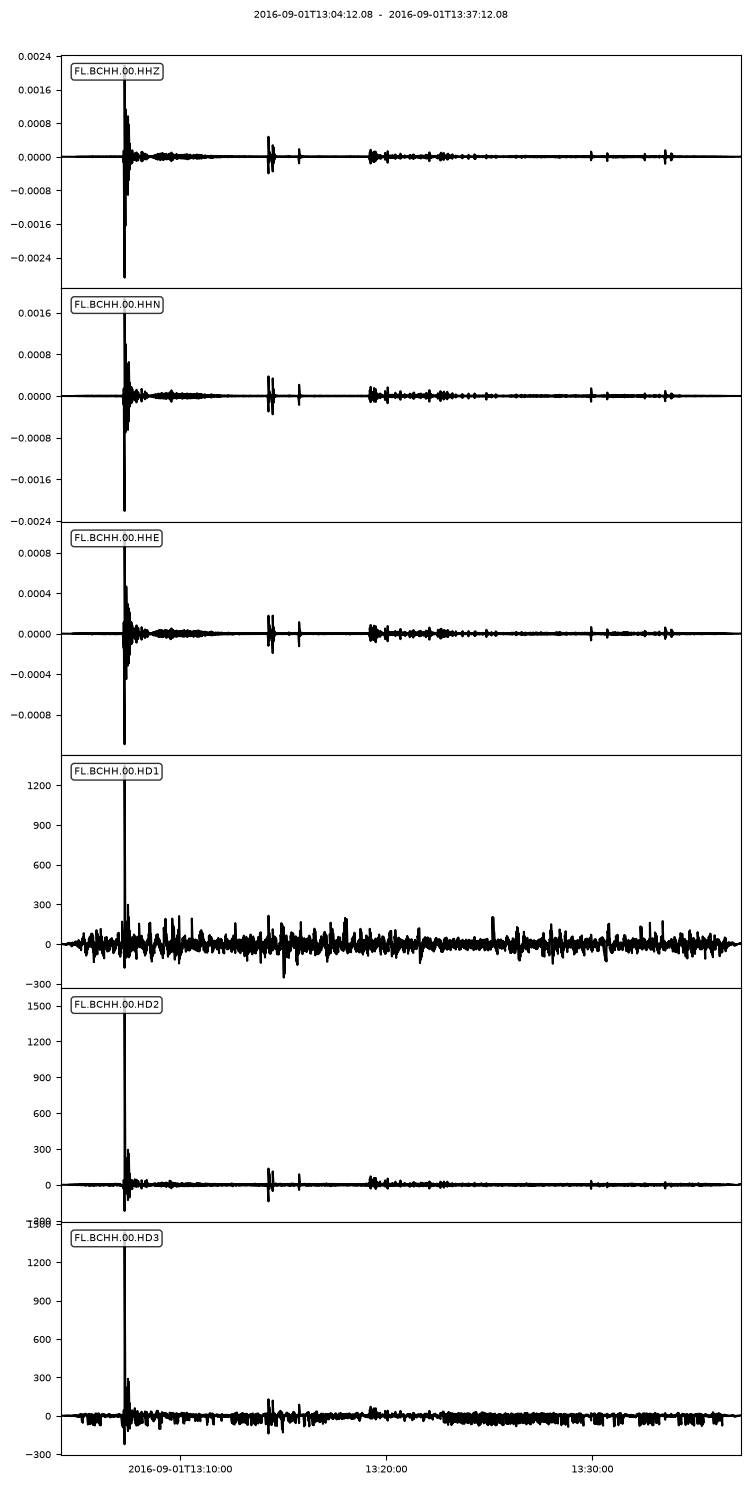

In [7]:
def read_corrected_bchh_stream(
    pickle_file: Path,
    miniseed_file: Path,
    *,
    starttime: UTCDateTime,
    endtime: UTCDateTime,
) -> Stream:
    """Load the authoritative response-corrected BCHH stream.

    Prefer Pickle because it preserves custom ObsPy metadata such as units and
    response-processing notes. Fall back to miniSEED for interoperability.
    """
    if pickle_file.exists():
        stream = read(str(pickle_file), format="PICKLE")
        source_file = pickle_file
    elif miniseed_file.exists():
        stream = read(str(miniseed_file), format="MSEED")
        source_file = miniseed_file
        warnings.warn(
            "Loaded corrected miniSEED rather than Pickle. Custom trace metadata "
            "such as units may not be preserved."
        )
    else:
        raise FileNotFoundError(
            "No corrected BCHH stream found. Run "
            "01_correct_bchh_instrument_response_final.ipynb first.\n"
            f"Expected one of:\n  {pickle_file}\n  {miniseed_file}"
        )

    stream.trim(starttime, endtime, pad=False)
    stream.sort(keys=["station", "channel"])

    expected_channels = set(CHANNEL_ORDER)
    loaded_channels = {trace.stats.channel for trace in stream}
    missing_channels = expected_channels.difference(loaded_channels)
    if missing_channels:
        raise ValueError(
            f"Corrected stream is missing channels: {sorted(missing_channels)}"
        )

    print(f"Loaded corrected BCHH stream from:\n  {source_file}")
    return stream


st_corr = read_corrected_bchh_stream(
    CORRECTED_PICKLE_FILE,
    CORRECTED_MSEED_FILE,
    starttime=EXPLOSION_TIME - PRE_EVENT_SEC,
    endtime=EXPLOSION_TIME + POST_EVENT_SEC,
)

print(st_corr)
for trace in st_corr:
    print(
        trace.id,
        trace.stats.starttime,
        trace.stats.endtime,
        trace.stats.sampling_rate,
        trace.stats.npts,
        trace.stats.get("units", "units not stored"),
    )

loaded_duration_s = min(
    trace.stats.endtime - trace.stats.starttime
    for trace in st_corr
)
print(f"Common loaded duration: {loaded_duration_s / 60.0:.2f} minutes")

if CORRECTION_SUMMARY_FILE.exists():
    correction_summary_df = pd.read_csv(CORRECTION_SUMMARY_FILE)
    display(correction_summary_df)
else:
    correction_summary_df = None
    warnings.warn(
        f"Correction summary not found: {CORRECTION_SUMMARY_FILE}"
    )


st_corr.merge()
st_corr = st_corr.select(location="00")
st_corr.plot(equal_scale=False);


## 5. Channel-type helpers

Instrument-response removal has already been completed. These helpers are retained only because the plotting and display-preprocessing functions use them to apply channel-specific filters and labels.


In [8]:
def is_seismic_channel(channel: str) -> bool:
    """Return True for the BCHH high-gain seismic channels."""
    channel = channel.upper()
    return len(channel) >= 2 and channel[1] in {"H", "L"}


def is_infrasound_channel(channel: str) -> bool:
    """Return True for the BCHH pressure channels."""
    channel = channel.upper()
    return len(channel) >= 2 and channel[1] == "D"


def is_audio_channel(channel: str) -> bool:
    """Return True for imported video/audio waveform channels."""
    return channel.upper() in {"AUD", "AUDIO"}


## 6. Generic plotting and preprocessing utilities

ZEROPHASE filters can still introduce phase/group delay, so pick timing should be checked against minimally processed traces as well.


In [9]:
def trace_time_array_datetime64(tr):
    """Return matplotlib date numbers for all samples in a trace."""
    t0 = tr.stats.starttime.datetime
    sr = float(tr.stats.sampling_rate)
    seconds = np.arange(tr.stats.npts, dtype=float) / sr
    return mdates.date2num(t0) + seconds / 86400.0


def robust_scale(data, percentile=99.3):
    """Robust absolute-amplitude scale for display."""
    x = np.asarray(data, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return 1.0
    s = np.percentile(np.abs(x), percentile)
    return s if np.isfinite(s) and s > 0 else 1.0


def select_channels_in_order(st: Stream, channel_order) -> Stream:
    """Return a stream containing the first matching trace for each requested channel."""
    selected = Stream()
    for ch in channel_order:
        matches = st.select(channel=ch)
        if len(matches) == 0:
            matches = Stream([tr for tr in st if tr.stats.channel.upper() == ch.upper()])
        if len(matches):
            selected += matches[0].copy()
        else:
            warnings.warn(f'No trace found for channel {ch}')
    return selected


def preprocess_display_stream(
    st: Stream,
    starttime: UTCDateTime | None = None,
    endtime: UTCDateTime | None = None,
    infra_filter: dict | None = None,
    seis_filter: dict | None = None,
) -> Stream:
    """Trim, detrend, taper, and filter a stream for display only."""
    out = Stream()
    for tr0 in st:
        tr = tr0.copy()
        if starttime is not None and endtime is not None:
            tr.trim(starttime, endtime, pad=True, fill_value=0.0)
        tr.detrend('demean')
        tr.detrend('linear')
        tr.taper(max_percentage=0.005)

        ch = tr.stats.channel.upper()
        if is_infrasound_channel(ch) and infra_filter is not None:
            tr.filter(**infra_filter)
        elif is_seismic_channel(ch) and seis_filter is not None:
            tr.filter(**seis_filter)

        out += tr
    return out


def acoustic_or_seismic_delay_s(
    channel: str,
    distance_m: float,
    acoustic_speed_mps: float,
    direct_seismic_speed_mps: float,
    hh_use_direct_seismic_speed: bool,
) -> float:
    """Return the travel-time correction for one physical BCHH channel."""
    ch = channel.upper()
    if is_audio_channel(ch):
        return 0.0
    if is_infrasound_channel(ch):
        return distance_m / acoustic_speed_mps
    if is_seismic_channel(ch):
        speed = direct_seismic_speed_mps if hh_use_direct_seismic_speed else acoustic_speed_mps
        return distance_m / speed
    return 0.0


def reduce_stream_to_source_time_physical(
    st: Stream,
    sensor_distances_m: dict,
    acoustic_speed_mps: float,
    direct_seismic_speed_mps: float,
    hh_use_direct_seismic_speed: bool,
    audio_delay_s: float,
) -> Stream:
    """Shift each trace earlier by its assumed source-to-receiver travel time."""
    st_red = st.copy()

    for tr in st_red:
        ch = tr.stats.channel.upper()

        if is_audio_channel(ch):
            delay_s = audio_delay_s
        elif ch in sensor_distances_m:
            delay_s = acoustic_or_seismic_delay_s(
                ch,
                distance_m=sensor_distances_m[ch],
                acoustic_speed_mps=acoustic_speed_mps,
                direct_seismic_speed_mps=direct_seismic_speed_mps,
                hh_use_direct_seismic_speed=hh_use_direct_seismic_speed,
            )
        else:
            delay_s = 0.0

        print(f"Reducing {tr.id} by {delay_s:.4f} s")
        tr.stats.starttime -= delay_s
        tr.stats.processing = tr.stats.get("processing", [])
        tr.stats.processing.append(f"reduced_time_shift_minus_{delay_s:.4f}_s")

    return st_red


def zerophase_tag(zerophase: bool) -> str:
    """Short filename tag for the filter phase convention."""
    return "zp_true" if bool(zerophase) else "zp_false"


def add_zerophase_tag(outfile_base: Path, zerophase: bool) -> Path:
    """Append the zerophase convention to an output filename stem."""
    return outfile_base.with_name(f"{outfile_base.name}_{zerophase_tag(zerophase)}")


def bandpass_filter_dict(freqmin, freqmax, corners=4, zerophase=False):
    """Build an ObsPy bandpass filter dictionary with explicit zerophase."""
    return {
        "type": "bandpass",
        "freqmin": float(freqmin),
        "freqmax": float(freqmax),
        "corners": int(corners),
        "zerophase": bool(zerophase),
    }


## 7. Build the response-corrected display stream


In [10]:
def build_overview_stream(
    st: Stream,
    plot_start: UTCDateTime,
    plot_end: UTCDateTime,
    zerophase: bool,
    infra_freqmin: float = 0.5,
    infra_freqmax: float = 25.0,
    seis_freqmin: float = 0.5,
    seis_freqmax: float = 25.0,
    corners: int = 4,
) -> Stream:
    """Build the filtered 30-minute display stream for one zerophase setting."""
    overview_infra_filter = bandpass_filter_dict(
        freqmin=infra_freqmin,
        freqmax=infra_freqmax,
        corners=corners,
        zerophase=zerophase,
    )
    overview_seis_filter = bandpass_filter_dict(
        freqmin=seis_freqmin,
        freqmax=seis_freqmax,
        corners=corners,
        zerophase=zerophase,
    )

    return preprocess_display_stream(
        st,
        starttime=plot_start,
        endtime=plot_end,
        infra_filter=overview_infra_filter,
        seis_filter=overview_seis_filter,
    )


st_ordered = select_channels_in_order(st_corr, CHANNEL_ORDER)
st_overview = build_overview_stream(
    st=st_ordered,
    plot_start=PLOT_START,
    plot_end=PLOT_END,
    zerophase=ZEROPHASE,
)

print(f"Overview stream built with ZEROPHASE={ZEROPHASE}")
print(st_overview)


Overview stream built with ZEROPHASE=False
6 Trace(s) in Stream:
FL.BCHH.00.HD1 | 2016-09-01T13:04:42.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 487501 samples
FL.BCHH.00.HD2 | 2016-09-01T13:04:42.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 487501 samples
FL.BCHH.00.HD3 | 2016-09-01T13:04:42.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 487501 samples
FL.BCHH.00.HHE | 2016-09-01T13:04:42.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 487501 samples
FL.BCHH.00.HHN | 2016-09-01T13:04:42.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 487501 samples
FL.BCHH.00.HHZ | 2016-09-01T13:04:42.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 487501 samples


## 8. Figure 2: 30-minute overview figure


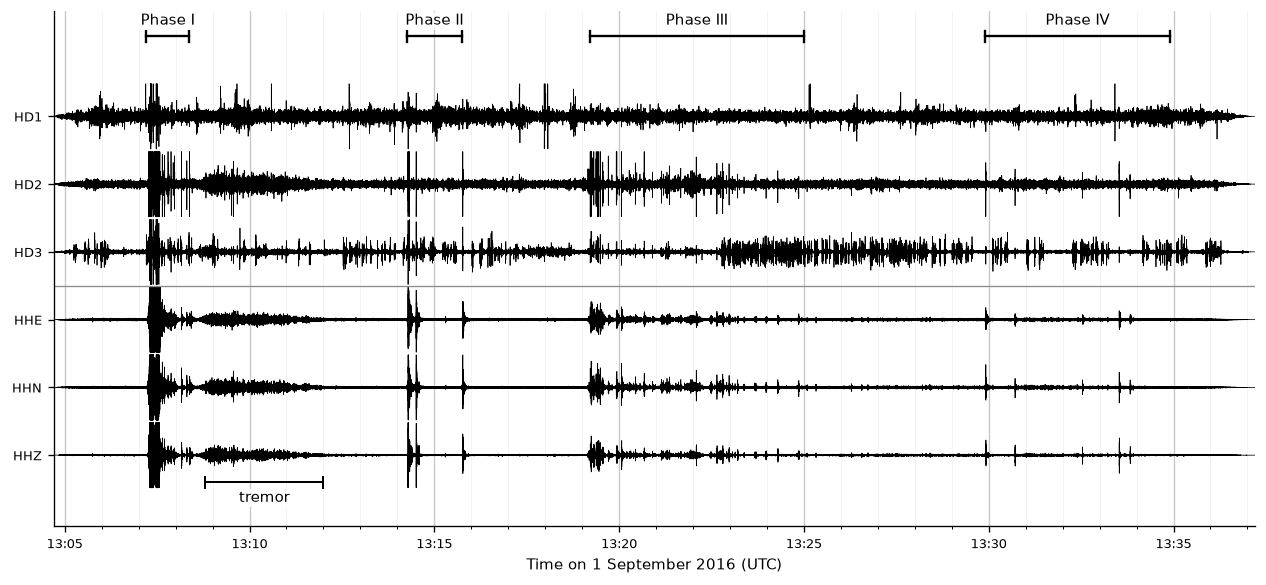

In [11]:
def add_time_bar(ax, t0, t1, y, text, above=True, lw=1.4, fontsize=9):
    """Draw a bracket-style time interval annotation."""
    x0 = mdates.date2num(t0.datetime)
    x1 = mdates.date2num(t1.datetime)

    ax.plot([x0, x1], [y, y], color="black", lw=lw, clip_on=False, zorder=20)
    tick = 0.08
    ax.plot([x0, x0], [y - tick, y + tick], color="black", lw=lw, clip_on=False, zorder=20)
    ax.plot([x1, x1], [y - tick, y + tick], color="black", lw=lw, clip_on=False, zorder=20)

    dy = 0.12 if above else -0.12
    va = "bottom" if above else "top"
    ax.text(
        (x0 + x1) / 2,
        y + dy,
        text,
        ha="center",
        va=va,
        fontsize=fontsize,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=1.0),
        clip_on=False,
        zorder=25,
    )


def make_overview_figure(
    st: Stream,
    outfile_base: Path,
    plot_start: UTCDateTime,
    plot_end: UTCDateTime,
    phases: list,
    explosion_time: UTCDateTime,
    tremor_start: UTCDateTime | None = None,
    tremor_end: UTCDateTime | None = None,
    normalize_by_group: bool = False,
    clip: float = 3.0,
    trace_gain: float = 0.15,
):
    """Make the 30-minute BCHH overview figure."""
    n = len(st)
    if n == 0:
        raise ValueError("No traces to plot")

    fig, ax = plt.subplots(figsize=(11.0, 5.8))
    offsets = np.arange(n)[::-1].astype(float)
    channel_labels = []

    infra_scales = [robust_scale(tr.data) for tr in st if is_infrasound_channel(tr.stats.channel)]
    seis_scales = [robust_scale(tr.data) for tr in st if is_seismic_channel(tr.stats.channel)]
    group_scale_infra = np.median(infra_scales) if infra_scales else 1.0
    group_scale_seis = np.median(seis_scales) if seis_scales else 1.0

    for i, tr in enumerate(st):
        y0 = offsets[i]
        ch = tr.stats.channel.upper()
        t = trace_time_array_datetime64(tr)
        data = np.nan_to_num(tr.data.astype(float), nan=0.0, posinf=0.0, neginf=0.0)

        if normalize_by_group:
            scale = group_scale_infra if is_infrasound_channel(ch) else group_scale_seis
        else:
            scale = robust_scale(data, percentile=99.3)

        y = y0 + np.clip(data / scale, -clip, clip) * trace_gain
        ax.plot(t, y, '-', color='black', lw=0.45, rasterized=True)
        channel_labels.append(ch)

    ax.set_yticks(offsets)
    ax.set_yticklabels(channel_labels)
    ax.set_ylim(-1.05, n + 0.55)
    ax.set_xlim(mdates.date2num(plot_start.datetime), mdates.date2num(plot_end.datetime))

    ax.xaxis.set_major_locator(mdates.MinuteLocator(byminute=range(0, 60, 5)))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.xaxis.set_minor_locator(mdates.MinuteLocator(interval=1))
    ax.grid(axis='x', which='major', color='0.78', lw=0.8)
    ax.grid(axis='x', which='minor', color='0.93', lw=0.4)
    ax.set_xlabel('Time on 1 September 2016 (UTC)')

    # Separator between infrasound and seismic channels for default 3+3 order.
    if n >= 6:
        ax.axhline(2.5, color='0.55', lw=0.8)

    phase_y = n + 0.18
    for name, t0, t1 in phases:
        if name.strip().lower() == 'phase i':
            t0 = explosion_time
        if t1 < plot_start or t0 > plot_end:
            continue
        add_time_bar(ax, max(t0, plot_start), min(t1, plot_end), phase_y, name, above=True)

    if tremor_start is not None and tremor_end is not None:
        if tremor_end >= plot_start and tremor_start <= plot_end:
            add_time_bar(
                ax,
                max(tremor_start, plot_start),
                min(tremor_end, plot_end),
                y=-0.4,
                text='tremor',
                above=False,
                lw=1.2,
            )

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    fig.subplots_adjust(left=0.08, right=0.99, top=0.88, bottom=0.14)

    for ext in ['png', 'pdf']:
        fig.savefig(outfile_base.with_suffix(f'.{ext}'), dpi=300, bbox_inches='tight', pad_inches=0.04)

    return fig, ax


overview_outfile = add_zerophase_tag(
    OUTDIR / 'fig03_bchh_30min_overview',
    ZEROPHASE,
)

fig, ax = make_overview_figure(
    st_overview,
    overview_outfile,
    PLOT_START,
    PLOT_END,
    phases=PHASES,
    explosion_time=EXPLOSION_TIME,
    tremor_start=TREMOR_START,
    tremor_end=TREMOR_END,
    normalize_by_group=False,
    clip=3.0,
    trace_gain=0.16,
)
plt.show()


## 9. Quick amplitude diagnostic

Use this to sanity-check response-corrected amplitudes before using the figures in the manuscript.


In [12]:
rows = []
for tr in st_ordered:
    x = np.asarray(tr.data, dtype=float)
    rows.append({
        'id': tr.id,
        'channel': tr.stats.channel,
        'units': getattr(tr.stats, 'units', ''),
        'sampling_rate': tr.stats.sampling_rate,
        'min': float(np.nanmin(x)),
        'max': float(np.nanmax(x)),
        'p99_abs': float(np.nanpercentile(np.abs(x), 99)),
        'p99_9_abs': float(np.nanpercentile(np.abs(x), 99.9)),
    })

try:
    import pandas as pd
    display(pd.DataFrame(rows))
except Exception:
    for r in rows:
        print(r)


,id,channel,units,sampling_rate,min,max,p99_abs,p99_9_abs
0,FL.BCHH.00.HD1,HD1,Pa,250.0,-253.017930,1349.141452,103.992350,152.265351
1,FL.BCHH.00.HD2,HD2,Pa,250.0,-219.103736,1557.411627,9.388561,45.357057
2,FL.BCHH.00.HD3,HD3,Pa,250.0,-222.554264,1434.860925,44.387080,73.983548
3,FL.BCHH.00.HHE,HHE,m/s,250.0,-0.001094,0.001004,0.000033,0.000188
4,FL.BCHH.00.HHN,HHN,m/s,250.0,-0.002207,0.001867,0.000043,0.000295
5,FL.BCHH.00.HHZ,HHZ,m/s,250.0,-0.002876,0.002173,0.000057,0.000476


## Peak and reduced pressure measurements

Peak acoustic pressures are measured independently on each calibrated infrasound
channel over a specified event window. For each sensor, we calculate the maximum
positive pressure, minimum negative pressure, and peak-to-peak pressure.

Pressures are reduced to a reference distance of 1 km assuming spherical geometric
spreading:


$p_{\mathrm{red}} = p_{\mathrm{obs}}\frac{r}{r_{\mathrm{ref}}}$


where $r$ is the surveyed source-to-sensor distance and
$r_{\mathrm{ref}} = 1000$ m. The positive reduced pressure is used as the
representative reduced peak overpressure. Negative and peak-to-peak reduced
pressures are retained to characterize waveform asymmetry.

The functions below can operate either on an already trimmed waveform segment or
on a longer stream together with an event time window. They can therefore be
applied to the principal explosion, the initial second-stage failure, the capsule
explosion, or every event in the catalogue.

In [13]:
from collections.abc import Mapping

# Surveyed source-to-sensor distances from SLC-40.
# Update these values if the final geometry table changes.
BCHH_INFRASOUND_DISTANCES_M = {
    "HD1": 1442.2,
    "HD2": 1410.2,
    "HD3": 1414.8,
}


def _channel_code(trace) -> str:
    """Return the final channel code, e.g. HD1, from an ObsPy Trace."""
    return str(trace.stats.channel).upper()


def measure_reduced_pressures(
    st_event: Stream,
    sensor_distances_m: Mapping[str, float],
    *,
    reference_distance_m: float = 1000.0,
    event_name: str | None = None,
    #highpass: bool = False,
) -> pd.DataFrame:
    """
    Measure observed and reduced pressures from a short calibrated event stream.

    Parameters
    ----------
    st_event
        ObsPy Stream containing calibrated infrasound traces in Pa. The stream
        should already be trimmed to the desired event window.
    sensor_distances_m
        Mapping from channel code, such as ``HD1``, to source-to-sensor
        distance in metres.
    reference_distance_m
        Distance to which pressures are reduced. The default is 1000 m.
    event_name
        Optional event label added to the output table.

    Returns
    -------
    pandas.DataFrame
        One row per infrasound channel, containing observed and reduced
        positive, negative, negative-magnitude, and peak-to-peak pressures.

    Notes
    -----
    Reduced pressure is calculated assuming spherical spreading:

        p_reduced = p_observed * distance / reference_distance

    The negative pressure retains its sign. ``negative_magnitude_pa`` is also
    included for convenient comparison with the positive peak.
    """
    if reference_distance_m <= 0:
        raise ValueError("reference_distance_m must be positive.")

    if len(st_event) == 0:
        raise ValueError("st_event contains no traces.")

    rows: list[dict[str, Any]] = []
    
    st_event2 = st_event.copy()
    #if highpass:
    #    st_event2.filter('highpass', freq=5, corners=2)
    for tr in st_event2:
        channel = _channel_code(tr)

        if channel not in sensor_distances_m:
            continue

        distance_m = float(sensor_distances_m[channel])
        if not np.isfinite(distance_m) or distance_m <= 0:
            raise ValueError(
                f"Invalid source distance for {channel}: {distance_m}"
            )

        data = np.asarray(tr.data, dtype=float)
        data = data[np.isfinite(data)]

        if data.size == 0:
            raise ValueError(f"{tr.id} contains no finite samples.")

        positive_peak_pa = float(np.max(data))
        negative_peak_pa = float(np.min(data))
        negative_magnitude_pa = abs(negative_peak_pa)
        peak_to_peak_pa = positive_peak_pa - negative_peak_pa

        reduction_factor = distance_m / reference_distance_m

        rows.append(
            {
                "event": event_name,
                "id": tr.id,
                "channel": channel,
                "starttime": tr.stats.starttime,
                "endtime": tr.stats.endtime,
                "sampling_rate_hz": float(tr.stats.sampling_rate),
                "npts": int(tr.stats.npts),
                "distance_m": distance_m,
                "reference_distance_m": float(reference_distance_m),
                "reduction_factor": reduction_factor,
                "positive_peak_pa": positive_peak_pa,
                "negative_peak_pa": negative_peak_pa,
                "negative_magnitude_pa": negative_magnitude_pa,
                "peak_to_peak_pa": peak_to_peak_pa,
                "positive_reduced_pa": positive_peak_pa * reduction_factor,
                "negative_reduced_pa": negative_peak_pa * reduction_factor,
                "negative_magnitude_reduced_pa": (
                    negative_magnitude_pa * reduction_factor
                ),
                "peak_to_peak_reduced_pa": peak_to_peak_pa * reduction_factor,
            }
        )

    if not rows:
        available = sorted({_channel_code(tr) for tr in st_event})
        expected = sorted(sensor_distances_m)
        raise ValueError(
            "No traces matched the distance dictionary. "
            f"Available channels: {available}; expected channels: {expected}"
        )

    result = pd.DataFrame(rows).sort_values("channel").reset_index(drop=True)

    # Add robust three-sensor summaries as a separate final row.
    numeric_columns = [
        "distance_m",
        "reduction_factor",
        "positive_peak_pa",
        "negative_peak_pa",
        "negative_magnitude_pa",
        "peak_to_peak_pa",
        "positive_reduced_pa",
        "negative_peak_pa",
        "negative_reduced_pa",
        "negative_magnitude_reduced_pa",
        "peak_to_peak_reduced_pa",
    ]

    summary = {
        "event": event_name,
        "id": "ARRAY_MEDIAN",
        "channel": "MEDIAN",
        "starttime": result["starttime"].min(),
        "endtime": result["endtime"].max(),
        "sampling_rate_hz": result["sampling_rate_hz"].median(),
        "npts": np.nan,
        "reference_distance_m": float(reference_distance_m),
    }

    for column in dict.fromkeys(numeric_columns):
        summary[column] = result[column].median()

    result = pd.concat(
        [result, pd.DataFrame([summary])],
        ignore_index=True,
    )

    return result


def measure_reduced_pressures_in_window(
    st: Stream,
    starttime: UTCDateTime | str,
    endtime: UTCDateTime | str,
    sensor_distances_m: Mapping[str, float],
    *,
    reference_distance_m: float = 1000.0,
    event_name: str | None = None,
    nearest_sample: bool = True,
    #highpass: bool = False,
) -> tuple[Stream, pd.DataFrame]:
    """
    Trim a calibrated stream to an event window and measure reduced pressures.

    Returns both the trimmed event stream and the measurement table.
    """
    t0 = UTCDateTime(starttime)
    t1 = UTCDateTime(endtime)

    if t1 <= t0:
        raise ValueError(f"endtime must follow starttime: {t0} to {t1}")

    st_event = st.copy()
    st_event.trim(
        starttime=t0,
        endtime=t1,
        nearest_sample=nearest_sample,
        pad=False,
    )

    '''
    # Retain only infrasound channels represented in the distance dictionary.
    st_event = Stream(
        traces=[
            tr for tr in st_event
            if _channel_code(tr) in sensor_distances_m
        ]
    )
    '''

    measurements = measure_reduced_pressures(
        st_event.select(channel='HD*'),
        sensor_distances_m,
        reference_distance_m=reference_distance_m,
        event_name=event_name,
        #highpass=highpass,
    )

    return st_event, measurements


def pressure_results_for_paper(
    measurements: pd.DataFrame,
) -> pd.DataFrame:
    """Return a compact, publication-oriented view of the measurements."""
    columns = [
        "event",
        "channel",
        "distance_m",
        "positive_peak_pa",
        "negative_peak_pa",
        "peak_to_peak_pa",
        "positive_reduced_pa",
        "negative_reduced_pa",
        "peak_to_peak_reduced_pa",
    ]

    output = measurements.loc[:, columns].copy()

    pressure_columns = [
        "positive_peak_pa",
        "negative_peak_pa",
        "peak_to_peak_pa",
        "positive_reduced_pa",
        "negative_reduced_pa",
        "peak_to_peak_reduced_pa",
    ]

    output["distance_m"] = output["distance_m"].round(1)
    output[pressure_columns] = output[pressure_columns].round(1)

    return output

In [14]:
print(st_corr)

6 Trace(s) in Stream:
FL.BCHH.00.HD1 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HD2 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HD3 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HHE | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HHN | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HHZ | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples


,event,channel,distance_m,positive_peak_pa,negative_peak_pa,peak_to_peak_pa,positive_reduced_pa,negative_reduced_pa,peak_to_peak_reduced_pa
0,Principal explosion,HD1,1442.2,1349.1,-179.0,1528.1,1945.7,-258.2,2203.9
1,Principal explosion,HD2,1410.2,1557.4,-219.1,1776.5,2196.3,-309.0,2505.2
2,Principal explosion,HD3,1414.8,1434.9,-222.6,1657.4,2030.0,-314.9,2344.9
3,Principal explosion,MEDIAN,1414.8,1434.9,-219.1,1657.4,2030.0,-309.0,2344.9


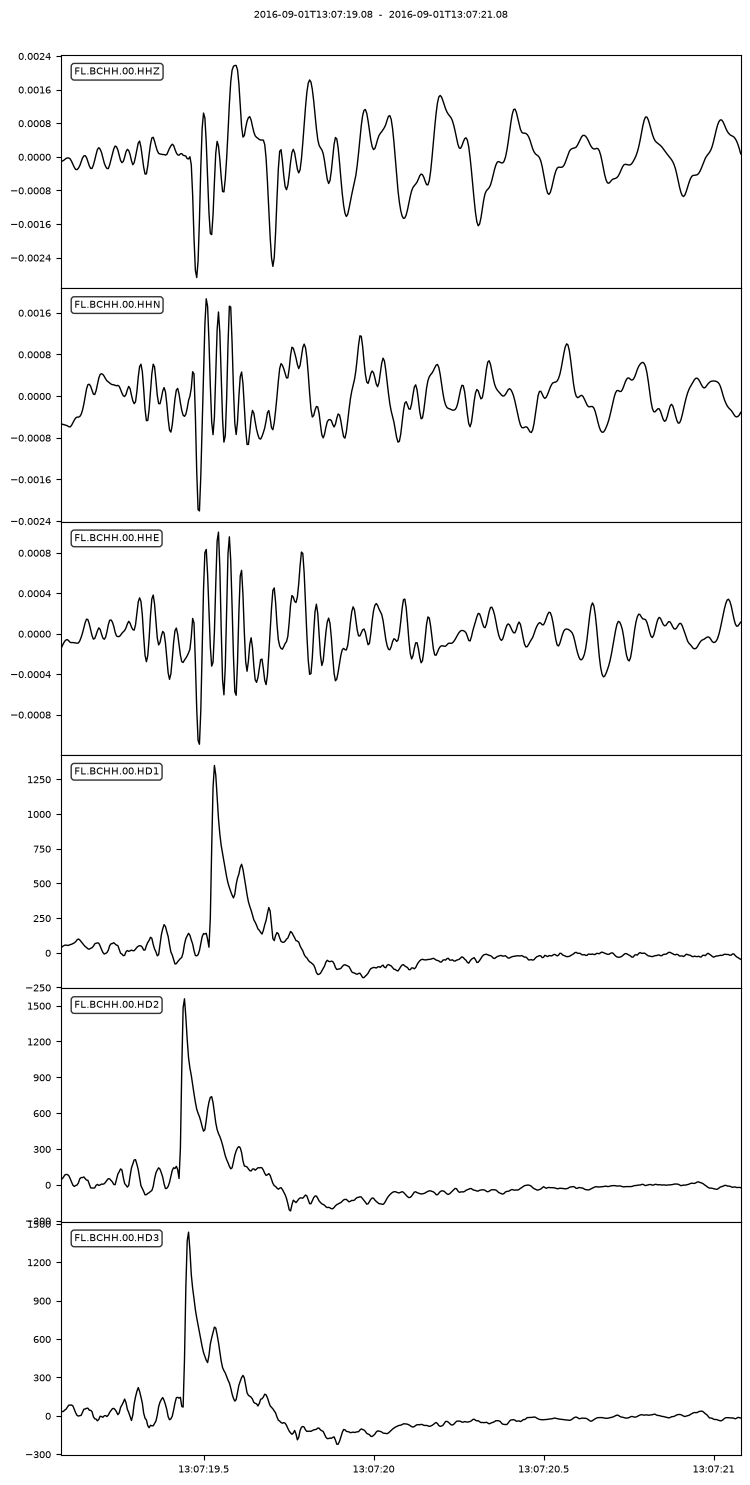

In [15]:
MAIN_EXPLOSION_START = EXPLOSION_TIME + 7
MAIN_EXPLOSION_END = EXPLOSION_TIME + 9

st_main_explosion, main_explosion_pressures = (
    measure_reduced_pressures_in_window(
        st_corr,
        starttime=MAIN_EXPLOSION_START,
        endtime=MAIN_EXPLOSION_END,
        sensor_distances_m=BCHH_INFRASOUND_DISTANCES_M,
        reference_distance_m=1000.0,
        event_name="Principal explosion",
    )
)

display(pressure_results_for_paper(main_explosion_pressures))
#st_corr.plot(startttime=st_main_explosion[0].stats.starttime, endtime=st_main_explosion[0].stats.endtime, equal_scale=False);
st_main_explosion.plot(equal_scale=False);

In [16]:

from collections.abc import Mapping

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator
from obspy import Stream, UTCDateTime


def plot_main_explosion(
    st_event: Stream,
    *,
    reference_time: UTCDateTime | str,
    pressure_results=None,
    title: str = "Principal explosion",
    seismic_channels: tuple[str, ...] = ("HHZ", "HHN", "HHE"),
    infrasound_channels: tuple[str, ...] = ("HD1", "HD2", "HD3"),
    seismic_labels: Mapping[str, str] | None = None,
    infrasound_labels: Mapping[str, str] | None = None,
    figsize: tuple[float, float] = (11.5, 6.8),
    outfile=None,
    add_measurements=False,
):
    """
    Plot the principal explosion as grouped seismic and infrasound panels.

    Parameters
    ----------
    st_event
        Response-corrected event stream. Seismic traces must be in m/s and
        infrasound traces in Pa.
    reference_time
        Time used for the relative x-axis.
    pressure_results
        Optional DataFrame returned by the pressure measurement function.
        When supplied, positive and negative pressure extrema are marked.
    title
        Figure title.
    outfile
        Optional output path. If supplied, the figure is saved.
    """
    reference_time = UTCDateTime(reference_time)

    if seismic_labels is None:
        seismic_labels = {
            "HHZ": "Vertical",
            "HHN": "North",
            "HHE": "East",
        }

    if infrasound_labels is None:
        infrasound_labels = {
            "HD1": "HD1",
            "HD2": "HD2",
            "HD3": "HD3",
        }

    seismic_traces = []
    for channel in seismic_channels:
        matches = st_event.select(channel=channel)
        if len(matches) != 1:
            raise ValueError(
                f"Expected one {channel} trace, found {len(matches)}."
            )
        seismic_traces.append(matches[0])

    pressure_traces = []
    for channel in infrasound_channels:
        matches = st_event.select(channel=channel)
        if len(matches) != 1:
            raise ValueError(
                f"Expected one {channel} trace, found {len(matches)}."
            )
        pressure_traces.append(matches[0])

    fig = plt.figure(figsize=figsize, constrained_layout=True)
    grid = fig.add_gridspec(
        nrows=3,
        ncols=2,
        width_ratios=(1.0, 1.25),
        wspace=0.08,
        hspace=0.05,
    )

    seismic_axes = [
        fig.add_subplot(grid[row, 0])
        for row in range(3)
    ]

    pressure_axes = [
        fig.add_subplot(grid[row, 1])
        for row in range(3)
    ]

    # Determine common limits within each instrument group.
    seismic_limit = max(
        np.nanmax(np.abs(np.asarray(tr.data, dtype=float)))
        for tr in seismic_traces
    )
    seismic_limit *= 1.08

    pressure_min = min(
        np.nanmin(np.asarray(tr.data, dtype=float))
        for tr in pressure_traces
    )
    pressure_max = max(
        np.nanmax(np.asarray(tr.data, dtype=float))
        for tr in pressure_traces
    )

    pressure_padding = 0.05 * (pressure_max - pressure_min)
    pressure_ylim = (
        pressure_min - pressure_padding,
        pressure_max + pressure_padding,
    )

    # Plot seismic components.
    for index, (ax, tr) in enumerate(
        zip(seismic_axes, seismic_traces)
    ):
        channel = tr.stats.channel
        time_s = tr.times(
            reftime=reference_time
        )
        data = np.asarray(tr.data, dtype=float)

        ax.plot(time_s, data, linewidth=0.9)
        ax.axhline(0.0, linewidth=0.5, alpha=0.5)

        ax.set_ylim(-seismic_limit, seismic_limit)
        ax.yaxis.set_major_locator(MaxNLocator(nbins=4))

        ax.text(
            0.02,
            0.86,
            seismic_labels.get(channel, channel),
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=10,
            fontweight="bold",
        )

        if index < 2:
            ax.tick_params(labelbottom=False)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    # Plot infrasound channels.
    for index, (ax, tr) in enumerate(
        zip(pressure_axes, pressure_traces)
    ):
        channel = tr.stats.channel
        time_s = tr.times(
            reftime=reference_time
        )
        data = np.asarray(tr.data, dtype=float)

        ax.plot(time_s, data, linewidth=1.0)
        ax.axhline(0.0, linewidth=0.5, alpha=0.5)
        ax.set_ylim(*pressure_ylim)
        ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

        ax.text(
            0.02,
            0.86,
            infrasound_labels.get(channel, channel),
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=10,
            fontweight="bold",
        )

        # Mark positive and negative extrema.
        positive_index = int(np.nanargmax(data))
        negative_index = int(np.nanargmin(data))

        positive_time = time_s[positive_index]
        negative_time = time_s[negative_index]

        positive_value = data[positive_index]
        negative_value = data[negative_index]

        ax.scatter(
            positive_time,
            positive_value,
            s=24,
            zorder=4,
        )
        ax.scatter(
            negative_time,
            negative_value,
            s=24,
            zorder=4,
        )

        ax.annotate(
            f"{positive_value:.0f} Pa",
            xy=(positive_time, positive_value),
            xytext=(5, -16),
            textcoords="offset points",
            fontsize=8,
            ha="left",
            va="top",
        )

        ax.annotate(
            f"{negative_value:.0f} Pa",
            xy=(negative_time, negative_value),
            xytext=(5, 7),
            textcoords="offset points",
            fontsize=8,
            ha="left",
            va="bottom",
        )

        if index < 2:
            ax.tick_params(labelbottom=False)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    # Shared x limits.
    all_traces = seismic_traces + pressure_traces

    xmin = min(
        tr.stats.starttime - reference_time
        for tr in all_traces
    )
    xmax = max(
        tr.stats.endtime - reference_time
        for tr in all_traces
    )

    for ax in seismic_axes + pressure_axes:
        ax.set_xlim(xmin, xmax)
        ax.grid(axis="x", linewidth=0.4, alpha=0.3)

    seismic_axes[0].set_title(
        "Ground velocity",
        fontsize=11,
        fontweight="bold",
    )
    pressure_axes[0].set_title(
        "Acoustic pressure",
        fontsize=11,
        fontweight="bold",
    )

    seismic_axes[1].set_ylabel(
        "Ground velocity (m s$^{-1}$)"
    )
    pressure_axes[1].set_ylabel(
        "Pressure (Pa)"
    )

    seismic_axes[-1].set_xlabel(
        f"Time relative to {reference_time.strftime('%H:%M:%S.%f')[:-3]} UTC (s)"
    )
    pressure_axes[-1].set_xlabel(
        f"Time relative to {reference_time.strftime('%H:%M:%S.%f')[:-3]} UTC (s)"
    )

    fig.suptitle(
        title,
        fontsize=13,
        fontweight="bold",
    )

    if pressure_results is not None and add_measurements:
        sensor_rows = pressure_results[
            pressure_results["channel"].isin(infrasound_channels)
        ]

        if len(sensor_rows) > 0:
            median_positive = sensor_rows[
                "positive_peak_pa"
            ].median()

            median_reduced = sensor_rows[
                "positive_reduced_pa"
            ].median()

            fig.text(
                0.995,
                0.91,
                (
                    f"Median positive peak: {median_positive / 1000:.2f} kPa; "
                    f"median reduced pressure at 1 km: "
                    f"{median_reduced / 1000:.2f} kPa"
                ),
                ha="right",
                va="bottom",
                fontsize=8.5,
            )

    if outfile is not None:
        fig.savefig(
            outfile,
            dpi=300,
            bbox_inches="tight",
        )

    return fig, {
        "seismic": seismic_axes,
        "infrasound": pressure_axes,
    }

In [17]:

from collections.abc import Mapping

import numpy as np
import pandas as pd
from obspy import Stream, UTCDateTime


def measure_reduced_pressures(
    st_event: Stream,
    sensor_distances_m: Mapping[str, float],
    *,
    reference_distance_m: float = 1000.0,
    event_name: str | None = None,
    baseline_start_s: float = 0.0,
    baseline_end_s: float = 0.75,
    signal_start_s: float | None = None,
    signal_end_s: float | None = None,
) -> pd.DataFrame:
    """
    Measure locally baseline-corrected pressure amplitudes.

    Times are specified in seconds relative to the start of each trace in
    ``st_event``.

    Parameters
    ----------
    st_event
        Calibrated infrasound event stream in Pa.
    sensor_distances_m
        Mapping from channel code to source-to-sensor distance in metres.
    reference_distance_m
        Reference distance for reduced pressure.
    event_name
        Optional event label.
    baseline_start_s, baseline_end_s
        Quiet pre-event interval used to estimate the local pressure baseline.
    signal_start_s, signal_end_s
        Interval over which extrema are measured. If omitted, measurement begins
        at ``baseline_end_s`` and continues to the end of the trace.
    """
    if reference_distance_m <= 0:
        raise ValueError("reference_distance_m must be positive.")

    if baseline_end_s <= baseline_start_s:
        raise ValueError("baseline_end_s must be greater than baseline_start_s.")

    if signal_start_s is None:
        signal_start_s = baseline_end_s

    rows = []

    for tr in st_event:
        channel = str(tr.stats.channel).upper()

        if channel not in sensor_distances_m:
            continue

        data = np.asarray(tr.data, dtype=float)
        sampling_rate = float(tr.stats.sampling_rate)
        times = tr.times()

        baseline_mask = (
            (times >= baseline_start_s)
            & (times < baseline_end_s)
            & np.isfinite(data)
        )

        if not np.any(baseline_mask):
            raise ValueError(
                f"No baseline samples found for {tr.id} in "
                f"{baseline_start_s:.3f}–{baseline_end_s:.3f} s."
            )

        baseline_pa = float(np.nanmedian(data[baseline_mask]))
        corrected_data = data - baseline_pa

        signal_mask = (
            (times >= signal_start_s)
            & np.isfinite(corrected_data)
        )

        if signal_end_s is not None:
            signal_mask &= times <= signal_end_s

        if not np.any(signal_mask):
            raise ValueError(
                f"No signal samples found for {tr.id} in the requested window."
            )

        signal_data = corrected_data[signal_mask]
        signal_times = times[signal_mask]

        positive_index = int(np.nanargmax(signal_data))
        negative_index = int(np.nanargmin(signal_data))

        positive_peak_pa = float(signal_data[positive_index])
        negative_peak_pa = float(signal_data[negative_index])
        peak_to_peak_pa = positive_peak_pa - negative_peak_pa

        distance_m = float(sensor_distances_m[channel])
        reduction_factor = distance_m / reference_distance_m

        rows.append(
            {
                "event": event_name,
                "id": tr.id,
                "channel": channel,
                "distance_m": distance_m,
                "baseline_pa": baseline_pa,
                "positive_peak_time_s": float(signal_times[positive_index]),
                "negative_peak_time_s": float(signal_times[negative_index]),
                "positive_peak_pa": positive_peak_pa,
                "negative_peak_pa": negative_peak_pa,
                "peak_to_peak_pa": peak_to_peak_pa,
                "positive_reduced_pa": positive_peak_pa * reduction_factor,
                "negative_reduced_pa": negative_peak_pa * reduction_factor,
                "peak_to_peak_reduced_pa": peak_to_peak_pa * reduction_factor,
            }
        )

    if not rows:
        raise ValueError("No infrasound channels matched sensor_distances_m.")

    result = (
        pd.DataFrame(rows)
        .sort_values("channel")
        .reset_index(drop=True)
    )

    summary_columns = [
        "distance_m",
        "baseline_pa",
        "positive_peak_pa",
        "negative_peak_pa",
        "peak_to_peak_pa",
        "positive_reduced_pa",
        "negative_reduced_pa",
        "peak_to_peak_reduced_pa",
    ]

    summary = {
        "event": event_name,
        "id": "ARRAY_MEDIAN",
        "channel": "MEDIAN",
        "positive_peak_time_s": np.nan,
        "negative_peak_time_s": np.nan,
    }

    for column in summary_columns:
        summary[column] = float(result[column].median())

    return pd.concat(
        [result, pd.DataFrame([summary])],
        ignore_index=True,
    )

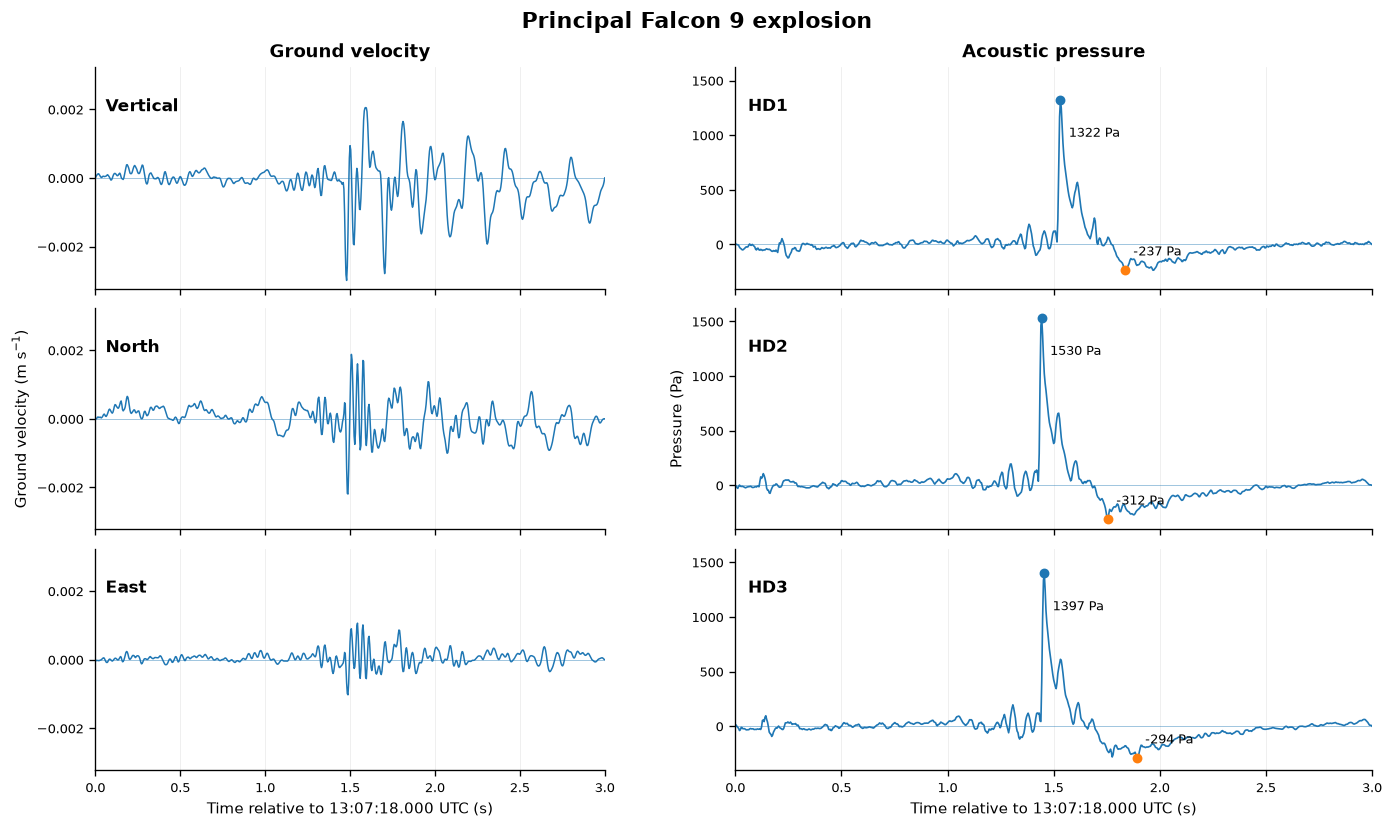

In [18]:
MAIN_EXPLOSION_START = EXPLOSION_TIME + 6 - 0.08
MAIN_EXPLOSION_END = EXPLOSION_TIME + 9 - 0.08

st_corr2 = st_corr.copy().filter(type='highpass', freq=0.1, corners=2)

st_main_explosion, main_explosion_pressures = (
    measure_reduced_pressures_in_window(
        st_corr2,
        starttime=MAIN_EXPLOSION_START,
        endtime=MAIN_EXPLOSION_END,
        sensor_distances_m=BCHH_INFRASOUND_DISTANCES_M,
        reference_distance_m=1000.0,
        event_name="Principal explosion",
    )
)

fig, axes = plot_main_explosion(
    st_main_explosion.detrend(),
    reference_time=MAIN_EXPLOSION_START,
    pressure_results=main_explosion_pressures,
    title="Principal Falcon 9 explosion",
    outfile=OUTDIR / "principal_explosion_waveforms.png",
)

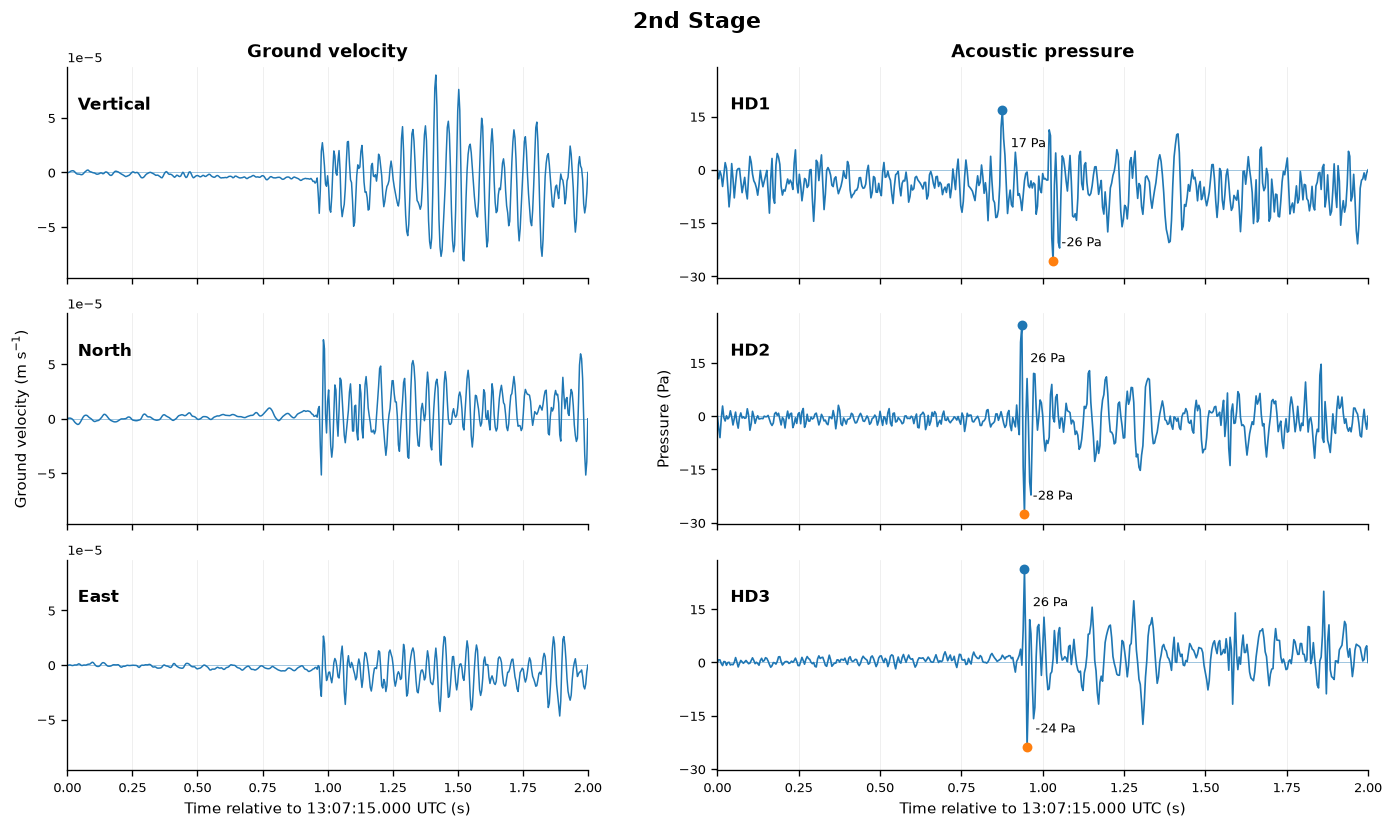

In [19]:
SECOND_STAGE_START = EXPLOSION_TIME + 3 - 0.08
SECOND_STAGE_END = EXPLOSION_TIME + 5 - 0.08

st_corr3 = st_corr.copy().filter(type='highpass', freq=20, corners=2)

st_second_stage, second_stage_pressures = (
    measure_reduced_pressures_in_window(
        st_corr3,
        starttime=SECOND_STAGE_START,
        endtime=SECOND_STAGE_END,
        sensor_distances_m=BCHH_INFRASOUND_DISTANCES_M,
        reference_distance_m=1000.0,
        event_name="2nd Stage",
        #highpass=True,
    )
)

fig, axes = plot_main_explosion(
    st_second_stage.detrend(),
    reference_time=SECOND_STAGE_START,
    pressure_results=second_stage_pressures,
    title="2nd Stage",
    outfile=OUTDIR / "second_stage_waveforms.png",
)

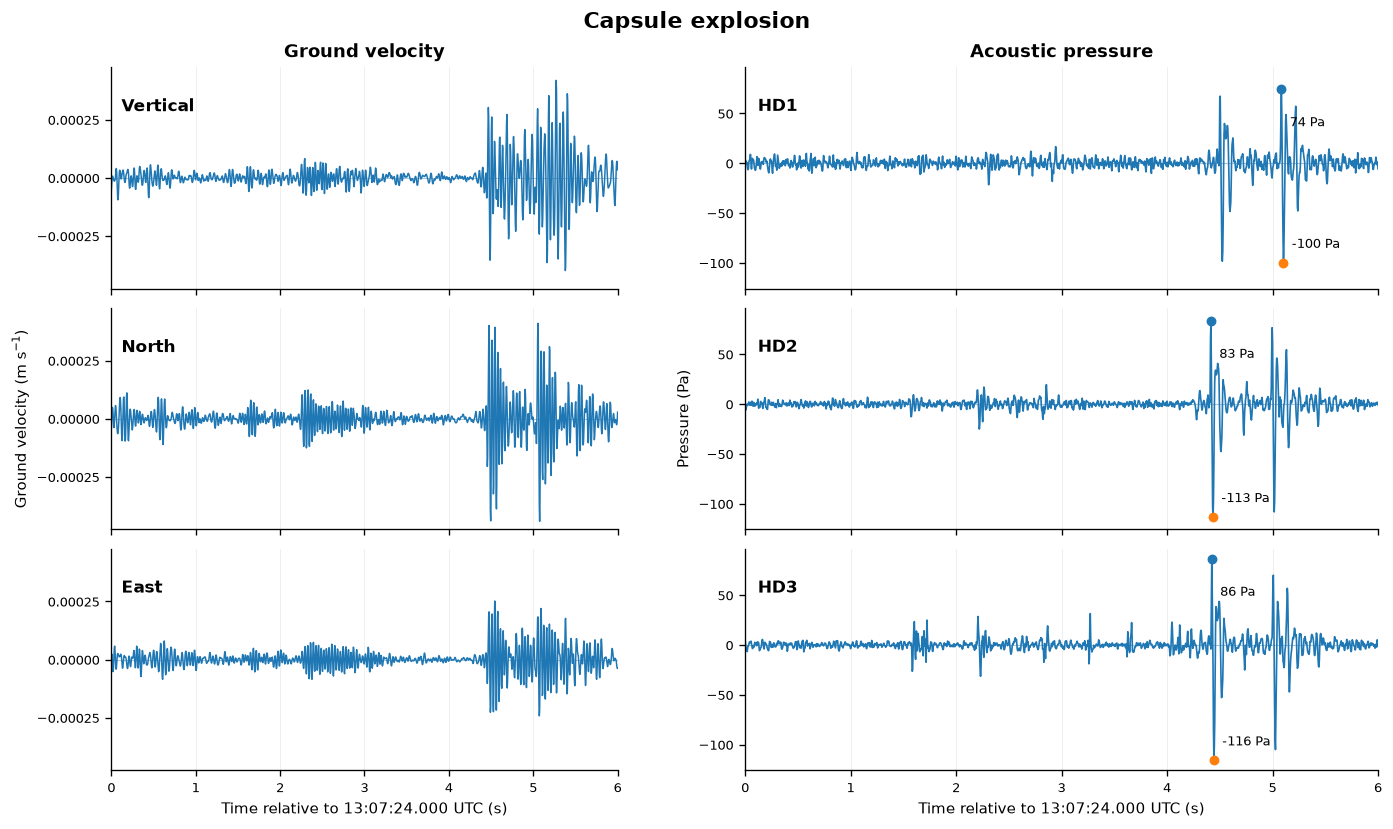

In [20]:
CAPSULE_START = CAPSULE + 0 - 0.6
CAPSULE_END = CAPSULE + 6 - 0.6

st_capsule, capsule_pressures = (
    measure_reduced_pressures_in_window(
        st_corr3,
        starttime=CAPSULE_START,
        endtime=CAPSULE_END,
        sensor_distances_m=BCHH_INFRASOUND_DISTANCES_M,
        reference_distance_m=1000.0,
        event_name="Capsule explosion",
    )
)

fig, axes = plot_main_explosion(
    st_capsule,
    reference_time=CAPSULE_START,
    pressure_results=capsule_pressures,
    title="Capsule explosion",
    outfile=OUTDIR / "capsule_explosion_waveforms.png",
)

## 10. Load synchronized video/audio track

The audio track is treated as an approximate source-time reference, not an independent calibrated acoustic sensor. If `librosa` or the MP3 file is unavailable, the rest of the notebook still works without audio.


In [21]:
def load_video_audio_as_stream(audio_file: Path, starttime: UTCDateTime, network='YT', station='SYNC', channel='AUD') -> Stream:
    """Load an MP3/WAV file as a single ObsPy trace."""
    try:
        import librosa
    except Exception as e:
        raise ImportError('librosa is required to load MP3 audio') from e

    y, sr = librosa.load(audio_file, sr=None)
    tr = Trace(data=np.asarray(y, dtype=np.float32))
    tr.stats.sampling_rate = sr
    tr.stats.network = network
    tr.stats.station = station
    tr.stats.location = ''
    tr.stats.channel = channel
    tr.stats.starttime = starttime
    return Stream([tr])


def prepare_audio_for_plot(
    st_audio: Stream,
    zoom_start: UTCDateTime | None = None,
    zoom_end: UTCDateTime | None = None,
    freqmin: float | None = None,
    freqmax: float | None = None,
    audio_time_shift_s: float | None = None,
    demean: bool = True,
    normalize: bool = True,
    zerophase: bool = False,
    corners: int = 4,
) -> Stream:
    """Prepare video audio for display using explicitly supplied filter parameters."""
    sta = st_audio.copy()
    for tr in sta:
        if demean:
            tr.detrend('demean')
        if freqmin is not None and freqmax is not None:
            tr.filter(
                'bandpass',
                freqmin=freqmin,
                freqmax=freqmax,
                corners=corners,
                zerophase=bool(zerophase),
            )
        if audio_time_shift_s is not None:
            tr.stats.starttime += audio_time_shift_s
        if zoom_start is not None and zoom_end is not None:
            tr.trim(zoom_start, zoom_end, pad=False)
        if normalize:
            tr.normalize()
    return sta


AUDIO_STARTTIME = UTCDateTime('2016-09-01T13:07:10.000')  # edit if resynchronized

st_audio_raw = load_video_audio_as_stream(
    audio_file=AUDIO_FILE,
    starttime=AUDIO_STARTTIME,
)


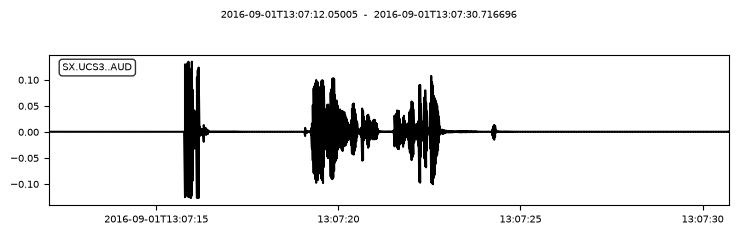

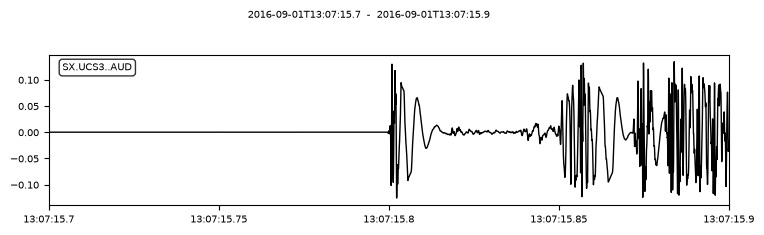

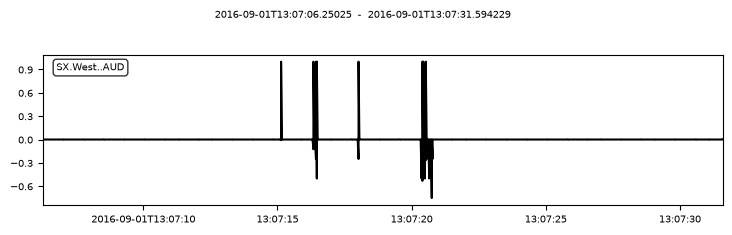

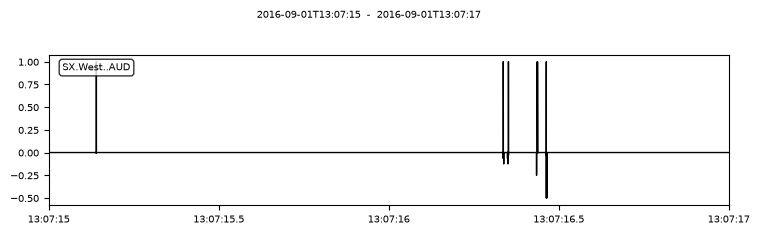

In [22]:
# Load other audio
UCS3_FILE = AUDIO_FILE.parent / 'camera_UCS3_audio.wav'
uc3_video_start = UTCDateTime("2016-09-01T13:07:12.05005")
st_ucs3_raw = load_video_audio_as_stream(UCS3_FILE, starttime=uc3_video_start, network='SX', station='UCS3', channel='AUD')
st_ucs3_raw.plot();
st_ucs3_raw.plot(starttime=UTCDateTime(2016,9,1,13,7,15.7), endtime=UTCDateTime(2016,9,1,13,7,15.9));

WESTFIXED_FILE = AUDIO_FILE.parent / 'camera_WestFixed_audio.wav'
wf_video_start = UTCDateTime("2016-09-01T13:07:06.25025")
st_wf_raw = load_video_audio_as_stream(WESTFIXED_FILE, starttime=wf_video_start, network='SX', station='West', channel='AUD')
st_wf_raw.plot();
st_wf_raw.plot(starttime=UTCDateTime(2016,9,1,13,7,15), endtime=UTCDateTime(2016,9,1,13,7,17));



6 Trace(s) in Stream:
FL.BCHH.00.HD1 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HD2 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HD3 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HHE | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HHN | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HHZ | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples


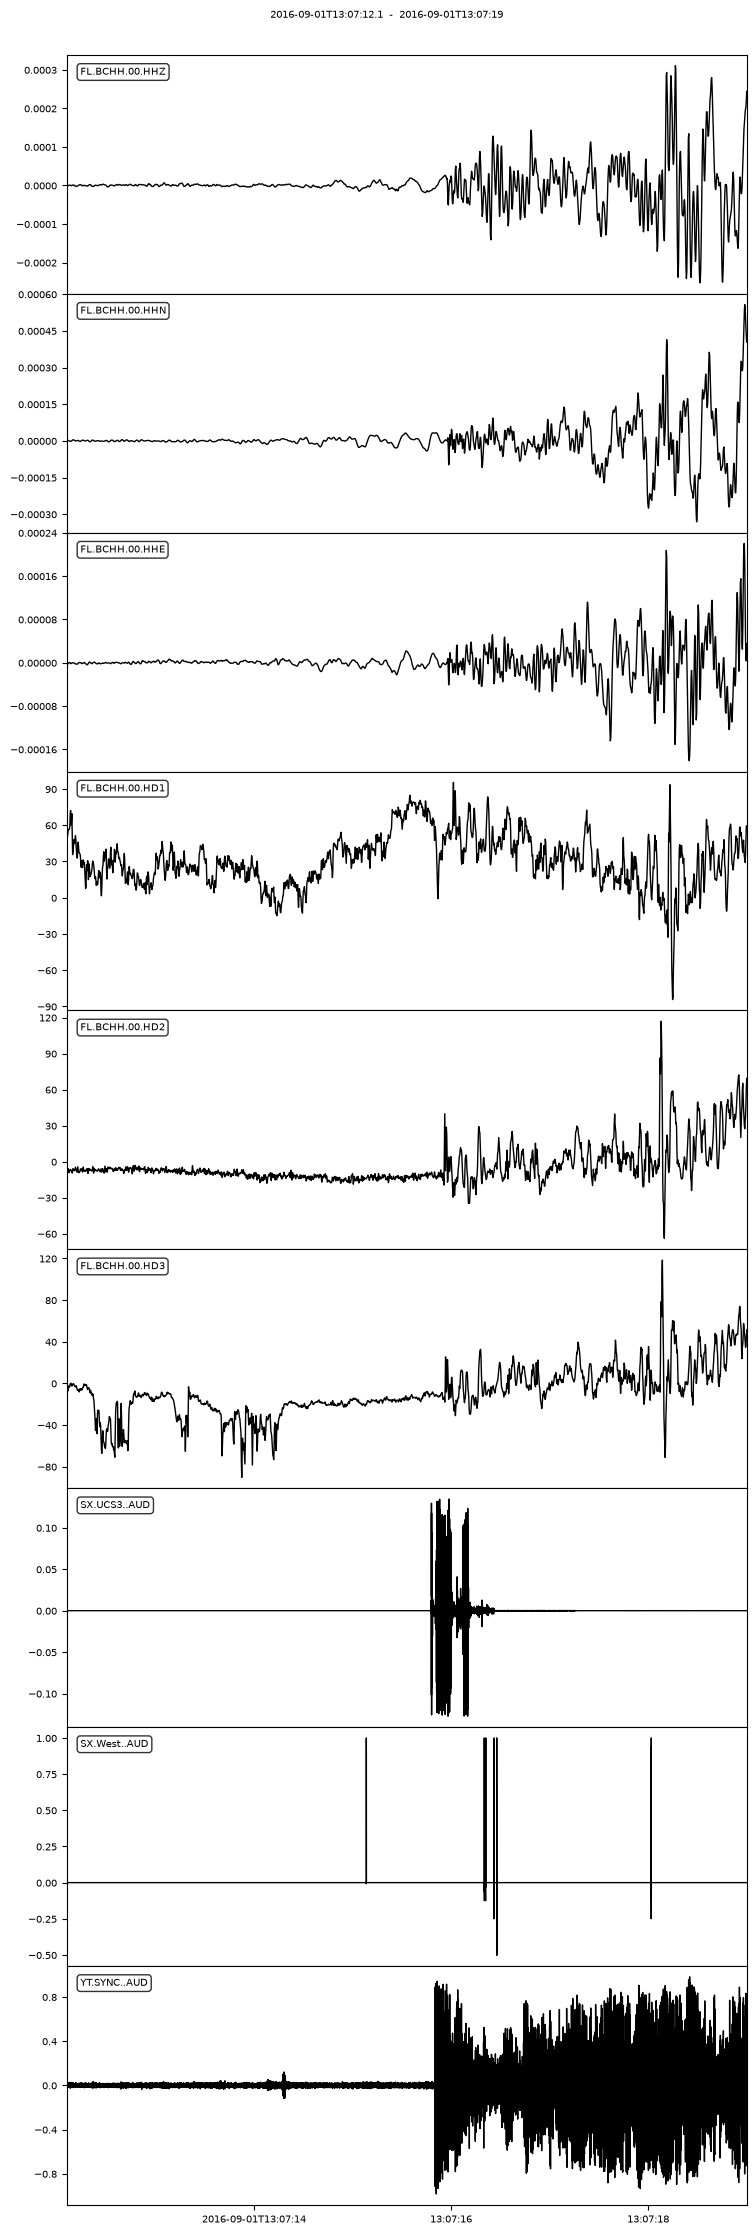

In [23]:
print(st_ordered)
(st_corr + st_ucs3_raw + st_audio_raw + st_wf_raw).plot(starttime=UTCDateTime(2016,9,1,13,7,12.1), endtime=UTCDateTime(2016,9,1,13,7,19), equal_scale=False);

## 11. Zoom-figure utilities

The same function can make either:

- **Observed-time plot**: traces remain in UTC; dashed arrival ticks show expected acoustic arrivals.
- **Reduced-time plot**: traces are shifted earlier by travel time; source-time red lines should align with arrivals if the assumed propagation speed and source picks are correct.


## 12. Build the zoom stream and figure

Set `REDUCE_TIME=False` to inspect observed UTC arrival times. Set `REDUCE_TIME=True` to shift traces into source time using the effective acoustic speed computed above.


In [24]:
def build_zoom_stream(
    stcentaur: Stream,
    staudio: Stream,
    zoom_start: UTCDateTime,
    zoom_end: UTCDateTime,
    zerophase: bool,
    infra_freqmin: float = 0.05,
    infra_freqmax: float = 120.0,
    seis_freqmin: float = 0.05,
    seis_freqmax: float = 120.0,
    audio_freqmin: float = 1000.0,
    audio_freqmax: float = 2000.0,
    corners: int = 4,
    pad_seconds: float = 10.0,
) -> Stream:
    """Build the filtered zoom stream, including audio, for one zerophase setting."""
    zoom_infra_filter = bandpass_filter_dict(
        freqmin=infra_freqmin,
        freqmax=infra_freqmax,
        corners=corners,
        zerophase=zerophase,
    )
    zoom_seis_filter = bandpass_filter_dict(
        freqmin=seis_freqmin,
        freqmax=seis_freqmax,
        corners=corners,
        zerophase=zerophase,
    )

    # Rebuild zoom data from response-corrected traces, not from the already filtered overview stream.
    st_zoom_local = preprocess_display_stream(
        stcentaur,
        starttime=zoom_start - pad_seconds,
        endtime=zoom_end + pad_seconds,
        infra_filter=zoom_infra_filter,
        seis_filter=zoom_seis_filter,
    )

    # Audio stays in its own clock convention here. Reduced-time shifting handles
    # audio_delay_s later in one place.
    st_audio_zoom_local = prepare_audio_for_plot(
        staudio,
        zoom_start=zoom_start - pad_seconds,
        zoom_end=zoom_end + pad_seconds,
        freqmin=audio_freqmin,
        freqmax=audio_freqmax,
        normalize=True,
        zerophase=zerophase,
        corners=corners,
    )

    return st_audio_zoom_local + st_zoom_local


def channel_delay_s(
    channel: str,
    sensor_distances_m: dict,
    acoustic_speed_mps: float,
    audio_delay_s: float,
) -> float:
    """
    Return propagation delay for one plotted channel.

    For BCHH we assume both infrasound and HH seismic channels record
    the ground-coupled airwave, so all physical BCHH channels use the
    acoustic travel time.

    Audio is treated separately because it may already be synchronized
    to video/source time, or may have a separate manual clock offset.
    """
    ch = channel.upper()

    if is_audio_channel(ch):
        return audio_delay_s

    if ch in sensor_distances_m:
        return sensor_distances_m[ch] / acoustic_speed_mps

    return 0.0


def reduce_stream_to_source_time_for_zoom(
    st: Stream,
    sensor_distances_m: dict,
    acoustic_speed_mps: float,
    audio_delay_s: float,
) -> Stream:
    """
    Shift traces from observed UTC into reduced/source time.

    After this correction, an airwave travelling at acoustic_speed_mps
    should align with the source event time.
    """
    st_red = st.copy()

    for tr in st_red:
        delay = channel_delay_s(
            channel=tr.stats.channel,
            sensor_distances_m=sensor_distances_m,
            acoustic_speed_mps=acoustic_speed_mps,
            audio_delay_s=audio_delay_s,
        )

        print(f"Reducing {tr.id} by {delay:.4f} s")
        tr.stats.starttime -= delay

    return st_red


def make_zoom_figure_simple(
    st: Stream,
    outfile_base: Path,
    zoom_start: UTCDateTime,
    zoom_end: UTCDateTime,
    source_events: dict,
    sensor_distances_m: dict,
    acoustic_speed_mps: float,
    audio_delay_s: float,
    event_window_s: float,
    reduced_time: bool = False,
    show_source_times: bool = True,
    show_predicted_arrivals: bool = True,
    show_event_windows: bool = False,
    normalize_by_group: bool = False,
    clip: float = 4.0,
    trace_gain: float = 0.18,
):
    """
    Plot BCHH zoom figure.

    Timing convention
    -----------------
    If reduced_time is False:
        traces are shown in observed UTC.
        predicted arrivals are plotted at source_time + travel_time.

    If reduced_time is True:
        traces have already had travel times removed.
        source times are plotted directly.
    """
    if len(st) == 0:
        raise ValueError("No traces to plot")

    fig, ax = plt.subplots(figsize=(11.0, 5.2))

    offsets = np.arange(len(st))[::-1].astype(float)
    channel_labels = []
    channel_y = {}

    infra_scales = [
        robust_scale(tr.data, percentile=99.5)
        for tr in st
        if is_infrasound_channel(tr.stats.channel)
    ]
    seis_scales = [
        robust_scale(tr.data, percentile=99.5)
        for tr in st
        if is_seismic_channel(tr.stats.channel)
    ]

    group_scale_infra = np.median(infra_scales) if infra_scales else 1.0
    group_scale_seis = np.median(seis_scales) if seis_scales else 1.0

    for i, tr in enumerate(st):
        y0 = offsets[i]
        ch = tr.stats.channel.upper()
        channel_y[ch] = y0

        trc = tr.copy().trim(zoom_start, zoom_end, pad=True, fill_value=0)

        t = trace_time_array_datetime64(trc)
        data = np.nan_to_num(
            trc.data.astype(float),
            nan=0.0,
            posinf=0.0,
            neginf=0.0,
        )

        if normalize_by_group:
            if is_audio_channel(ch):
                scale = robust_scale(data, percentile=99.5)
            elif is_infrasound_channel(ch):
                scale = group_scale_infra
            else:
                scale = group_scale_seis
        else:
            scale = robust_scale(data, percentile=99.5)

        if scale <= 0 or not np.isfinite(scale):
            scale = 1.0

        y = y0 + np.clip(data / scale, -clip, clip) * trace_gain
        ax.plot(t, y, "-", color="black", lw=0.55, rasterized=True, zorder=12)

        if is_audio_channel(ch):
            channel_labels.append("Audio\n1–2 kHz")
        else:
            channel_labels.append(ch)

    ax.set_yticks(offsets)
    ax.set_yticklabels(channel_labels)
    ax.set_ylim(-0.7, len(st) - 0.25)
    ax.set_xlim(
        mdates.date2num(zoom_start.datetime),
        mdates.date2num(zoom_end.datetime),
    )

    ax.xaxis.set_major_locator(mdates.SecondLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
    ax.xaxis.set_minor_locator(mdates.SecondLocator(interval=1))

    ax.grid(axis="x", which="major", color="0.78", lw=0.8, zorder=1)
    ax.grid(axis="x", which="minor", color="0.93", lw=0.4, zorder=1)
    ax.set_xlabel("Time on 1 September 2016 (UTC)")

    if len(st) >= 6:
        ax.axhline(2.5, color="0.55", lw=0.8, zorder=10)

    def draw_short_vline(x, y0, half_height=0.38, **kwargs):
        ax.vlines(x, y0 - half_height, y0 + half_height, **kwargs)

    ytop = len(st) - 0.15

    for label, source_time in source_events.items():

        if show_source_times and zoom_start <= source_time <= zoom_end:
            x = mdates.date2num(source_time.datetime)

            ax.axvline(
                x,
                color="firebrick",
                lw=1.1,
                alpha=0.85,
                zorder=25,
            )

            ax.text(
                x,
                ytop,
                label,
                rotation=90,
                ha="center",
                va="top",
                fontsize=8,
                color="firebrick",
                alpha=0.90,
                bbox=dict(
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.75,
                    pad=1.0,
                ),
                clip_on=False,
                zorder=30,
            )

        for ch, y0 in channel_y.items():

            if reduced_time:
                arrival_time = source_time
            else:
                delay = channel_delay_s(
                    channel=ch,
                    sensor_distances_m=sensor_distances_m,
                    acoustic_speed_mps=acoustic_speed_mps,
                    audio_delay_s=audio_delay_s,
                )
                arrival_time = source_time + delay

            if show_event_windows:
                t_left = arrival_time - event_window_s / 2
                t_right = arrival_time + event_window_s / 2

                if t_right >= zoom_start and t_left <= zoom_end:
                    ax.fill_betweenx(
                        [y0 - 0.42, y0 + 0.42],
                        mdates.date2num(max(t_left, zoom_start).datetime),
                        mdates.date2num(min(t_right, zoom_end).datetime),
                        color="0.75",
                        alpha=0.35,
                        lw=0,
                        zorder=18,
                    )

            if show_predicted_arrivals and zoom_start <= arrival_time <= zoom_end:
                x = mdates.date2num(arrival_time.datetime)

                color = "firebrick" if is_infrasound_channel(ch) else "0.25"

                draw_short_vline(
                    x,
                    y0,
                    color=color,
                    lw=0.9,
                    linestyles="--",
                    alpha=0.6,
                    zorder=22,
                )

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    fig.subplots_adjust(left=0.08, right=0.99, top=0.96, bottom=0.15)

    for ext in ["png", "pdf"]:
        fig.savefig(
            outfile_base.with_suffix(f".{ext}"),
            dpi=300,
            bbox_inches="tight",
            pad_inches=0.04,
        )

    return fig, ax


def make_zoom_variant(
    stcentaur: Stream,
    staudio: Stream,
    output_dir: Path,
    zerophase: bool,
    reduce_time: bool,
    window_start: UTCDateTime,
    window_end: UTCDateTime,
    source_events: dict,
    sensor_distances_m: dict,
    acoustic_speed_mps: float,
    audio_delay_s: float,
    event_window_s: float,
    outfile_stem: str = "fig03_bchh_20s_zoom_with_audio",
    show: bool = True,
    zoom_filter_settings: dict | None = None,
    plot_settings: dict | None = None,
):
    """Build and plot one zoom figure for a zerophase/reduced-time combination.

    All quantities that affect the result are arguments rather than hidden globals.
    """
    if zoom_filter_settings is None:
        zoom_filter_settings = {}
    if plot_settings is None:
        plot_settings = {}

    st_zoom_local = build_zoom_stream(
        stcentaur=stcentaur,
        staudio=staudio,
        zoom_start=window_start,
        zoom_end=window_end,
        zerophase=zerophase,
        **zoom_filter_settings,
    )

    if reduce_time:
        st_zoom_plot_local = reduce_stream_to_source_time_for_zoom(
            st=st_zoom_local,
            sensor_distances_m=sensor_distances_m,
            acoustic_speed_mps=acoustic_speed_mps,
            audio_delay_s=audio_delay_s,
        )
        timing_tag = "reduced"
    else:
        st_zoom_plot_local = st_zoom_local.copy()
        timing_tag = "observed"

    st_zoom_plot_local.trim(window_start, window_end, pad=False)

    outfile_local = output_dir / f"{outfile_stem}_{timing_tag}_{zerophase_tag(zerophase)}"

    print(
        f"Plotting {outfile_local.name}: "
        f"ZEROPHASE={zerophase}, REDUCE_TIME={reduce_time}, "
        f"acoustic speed={acoustic_speed_mps:.1f} m/s"
    )

    fig, ax = make_zoom_figure_simple(
        st=st_zoom_plot_local,
        outfile_base=outfile_local,
        zoom_start=window_start,
        zoom_end=window_end,
        source_events=source_events,
        sensor_distances_m=sensor_distances_m,
        acoustic_speed_mps=acoustic_speed_mps,
        audio_delay_s=audio_delay_s,
        event_window_s=event_window_s,
        reduced_time=reduce_time,
        show_source_times=plot_settings.get("show_source_times", True),
        show_predicted_arrivals=plot_settings.get("show_predicted_arrivals", not reduce_time),
        show_event_windows=plot_settings.get("show_event_windows", False),
        normalize_by_group=plot_settings.get("normalize_by_group", False),
        clip=plot_settings.get("clip", 1.2),
        trace_gain=plot_settings.get("trace_gain", 0.4),
    )

    if show:
        plt.show()
    else:
        plt.close(fig)

    return {
        "zerophase": zerophase,
        "reduce_time": reduce_time,
        "stream": st_zoom_plot_local,
        "outfile": outfile_local,
        "fig": fig,
        "ax": ax,
    }



Acoustic speed = 348.8 m/s
Wind speed = 2.8 m/s
Effective acoustic speed = 348.8 m/s
Adding a time adjustment of 0.20 s to align Centaur data to SpaceX video event time markers
Adjusted speed from 348.8 m/s to 366.8 m/s to match the time adjustment
Audio is delayed by 3.75 s
Reducing YT.SYNC..AUD by 3.7550 s
Reducing FL.BCHH.00.HD1 by 3.9254 s
Reducing FL.BCHH.00.HD2 by 3.8392 s
Reducing FL.BCHH.00.HD3 by 3.8515 s
Reducing FL.BCHH.00.HHE by 3.8707 s
Reducing FL.BCHH.00.HHN by 3.8707 s
Reducing FL.BCHH.00.HHZ by 3.8707 s
Plotting fig03_bchh_20s_zoom_with_audio_reduced_zp_false: ZEROPHASE=False, REDUCE_TIME=True, acoustic speed=366.8 m/s


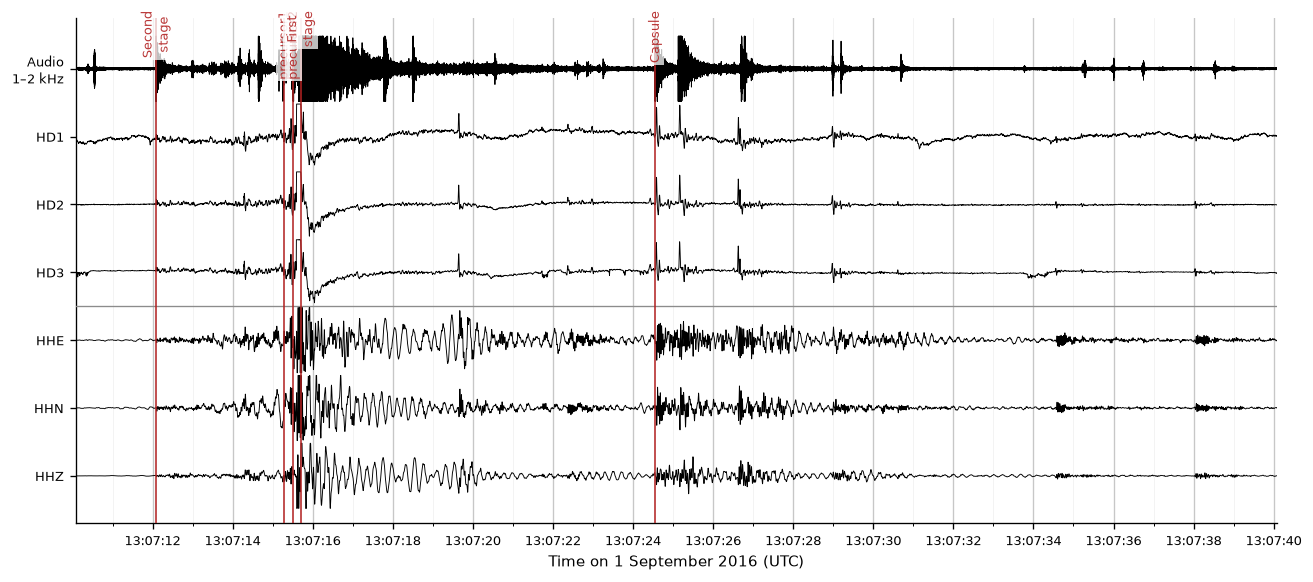

Reducing YT.SYNC..AUD by 3.7550 s
Reducing FL.BCHH.00.HD1 by 3.9254 s
Reducing FL.BCHH.00.HD2 by 3.8392 s
Reducing FL.BCHH.00.HD3 by 3.8515 s
Reducing FL.BCHH.00.HHE by 3.8707 s
Reducing FL.BCHH.00.HHN by 3.8707 s
Reducing FL.BCHH.00.HHZ by 3.8707 s
Plotting fig03_bchh_20s_zoom_with_audio_reduced_zp_true: ZEROPHASE=True, REDUCE_TIME=True, acoustic speed=366.8 m/s


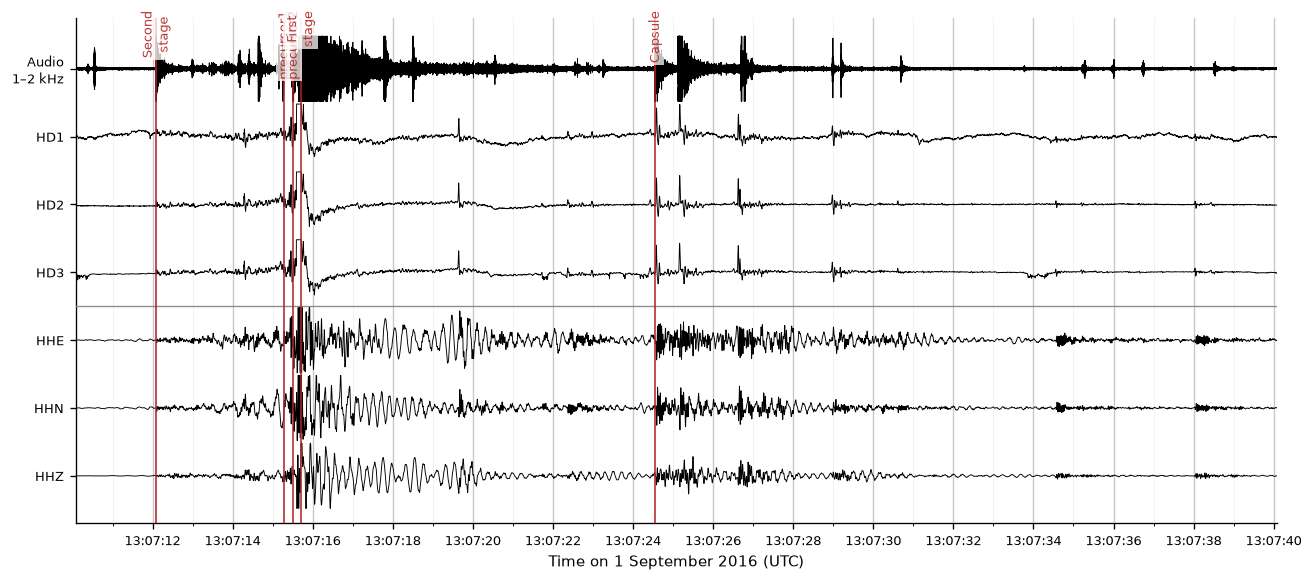

Reducing YT.SYNC..AUD by 3.7550 s
Reducing FL.BCHH.00.HD1 by 3.9254 s
Reducing FL.BCHH.00.HD2 by 3.8392 s
Reducing FL.BCHH.00.HD3 by 3.8515 s
Reducing FL.BCHH.00.HHE by 3.8707 s
Reducing FL.BCHH.00.HHN by 3.8707 s
Reducing FL.BCHH.00.HHZ by 3.8707 s
Plotting fig03_bchh_first_stage_closeup_with_audio_reduced_zp_false: ZEROPHASE=False, REDUCE_TIME=True, acoustic speed=366.8 m/s


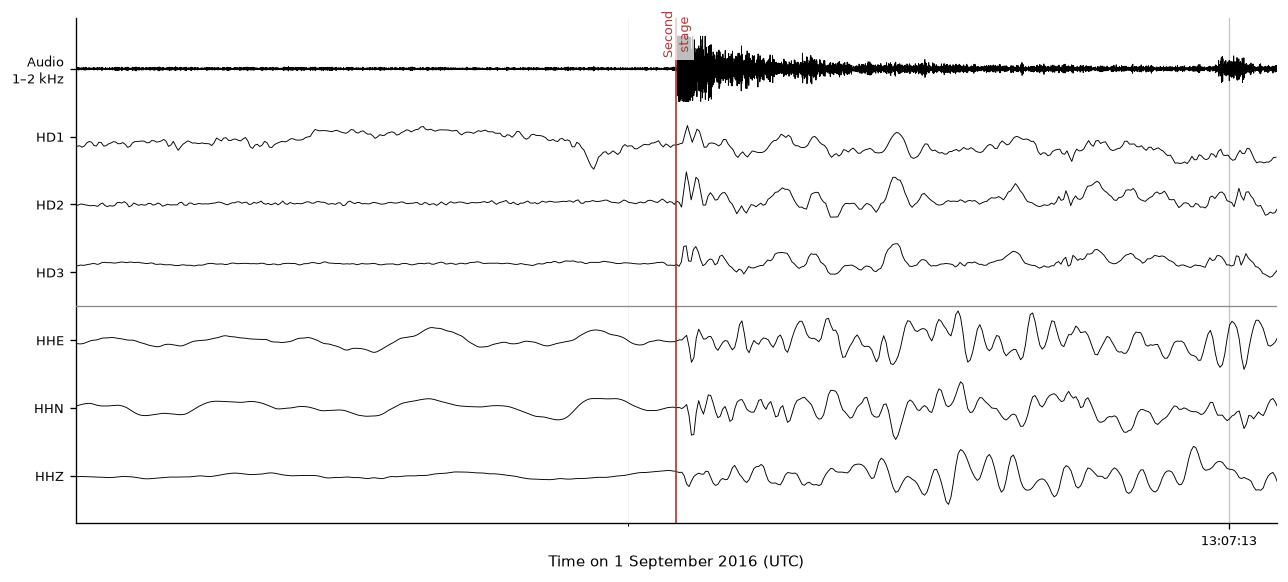

Reducing YT.SYNC..AUD by 3.7550 s
Reducing FL.BCHH.00.HD1 by 3.9254 s
Reducing FL.BCHH.00.HD2 by 3.8392 s
Reducing FL.BCHH.00.HD3 by 3.8515 s
Reducing FL.BCHH.00.HHE by 3.8707 s
Reducing FL.BCHH.00.HHN by 3.8707 s
Reducing FL.BCHH.00.HHZ by 3.8707 s
Plotting fig03_bchh_first_stage_closeup_with_audio_reduced_zp_true: ZEROPHASE=True, REDUCE_TIME=True, acoustic speed=366.8 m/s


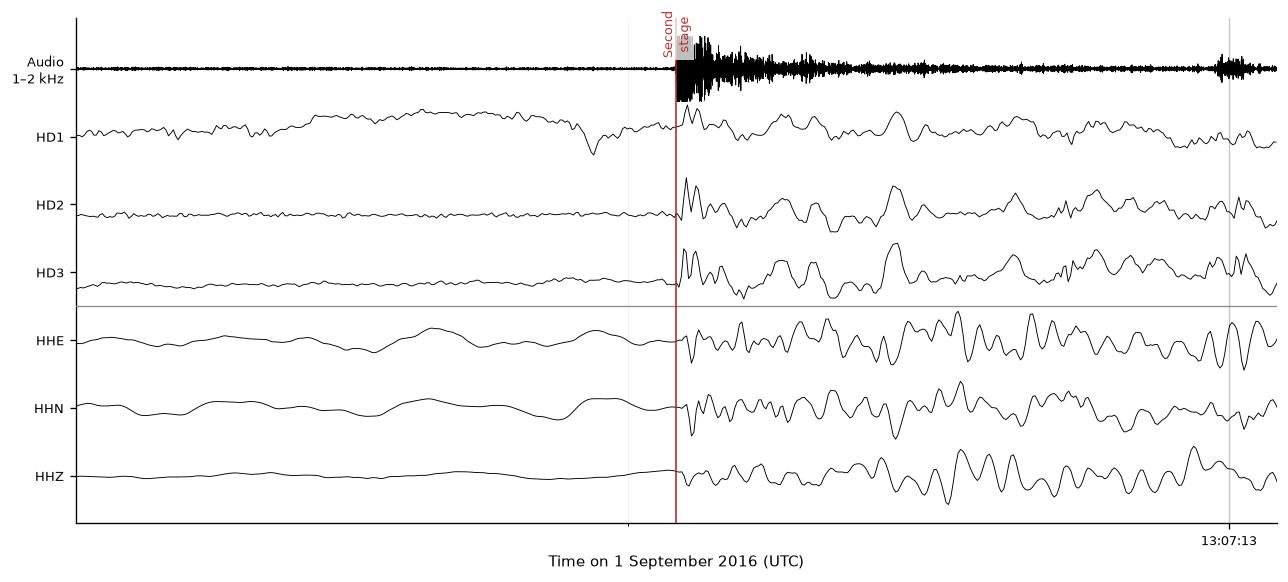

Reducing YT.SYNC..AUD by 3.7550 s
Reducing FL.BCHH.00.HD1 by 3.9254 s
Reducing FL.BCHH.00.HD2 by 3.8392 s
Reducing FL.BCHH.00.HD3 by 3.8515 s
Reducing FL.BCHH.00.HHE by 3.8707 s
Reducing FL.BCHH.00.HHN by 3.8707 s
Reducing FL.BCHH.00.HHZ by 3.8707 s
Plotting fig03_bchh_first_stage_closeup_with_audio_reduced_zp_false: ZEROPHASE=False, REDUCE_TIME=True, acoustic speed=366.8 m/s


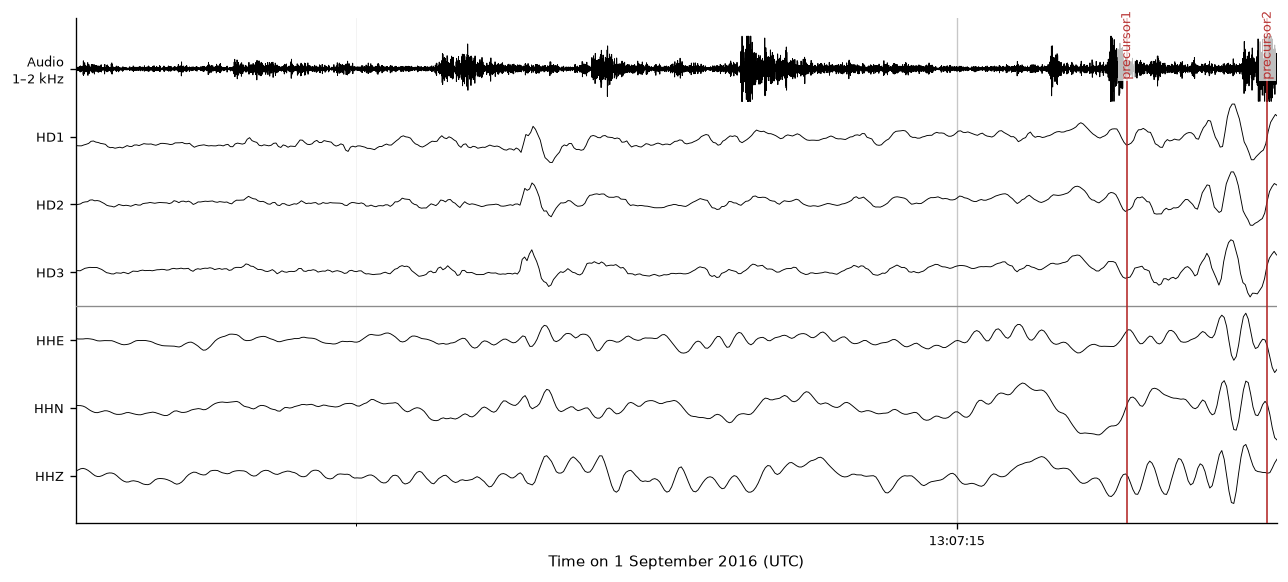

Reducing YT.SYNC..AUD by 3.7550 s
Reducing FL.BCHH.00.HD1 by 3.9254 s
Reducing FL.BCHH.00.HD2 by 3.8392 s
Reducing FL.BCHH.00.HD3 by 3.8515 s
Reducing FL.BCHH.00.HHE by 3.8707 s
Reducing FL.BCHH.00.HHN by 3.8707 s
Reducing FL.BCHH.00.HHZ by 3.8707 s
Plotting fig03_bchh_first_stage_closeup_with_audio_reduced_zp_true: ZEROPHASE=True, REDUCE_TIME=True, acoustic speed=366.8 m/s


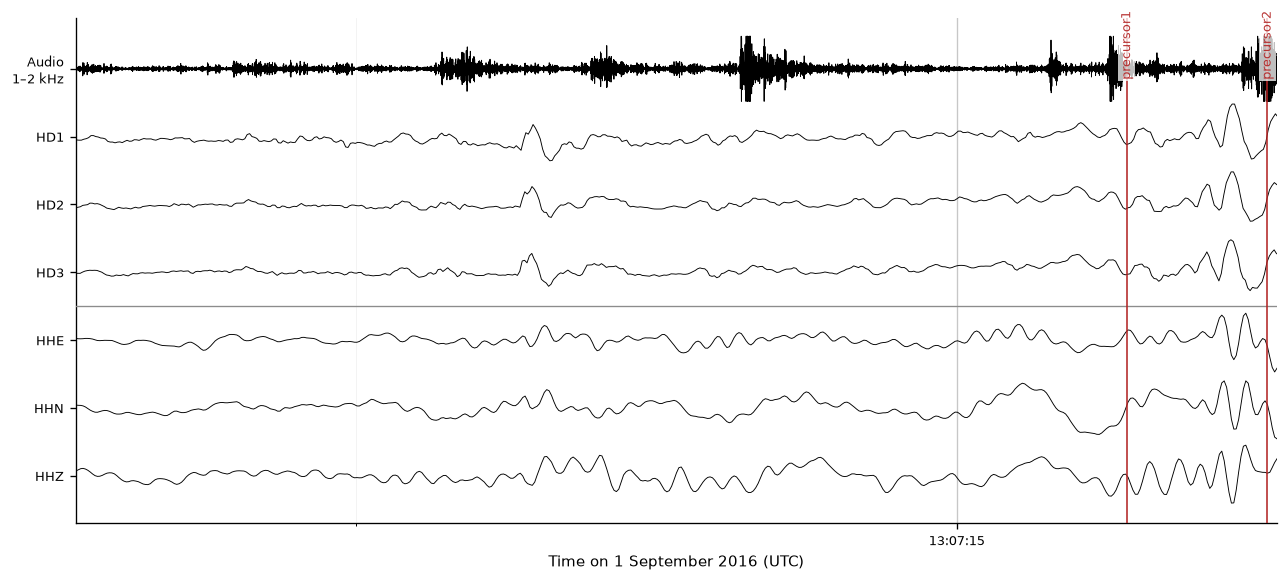

Reducing YT.SYNC..AUD by 3.7550 s
Reducing FL.BCHH.00.HD1 by 3.9254 s
Reducing FL.BCHH.00.HD2 by 3.8392 s
Reducing FL.BCHH.00.HD3 by 3.8515 s
Reducing FL.BCHH.00.HHE by 3.8707 s
Reducing FL.BCHH.00.HHN by 3.8707 s
Reducing FL.BCHH.00.HHZ by 3.8707 s
Plotting fig03_bchh_first_stage_closeup_with_audio_reduced_zp_false: ZEROPHASE=False, REDUCE_TIME=True, acoustic speed=366.8 m/s


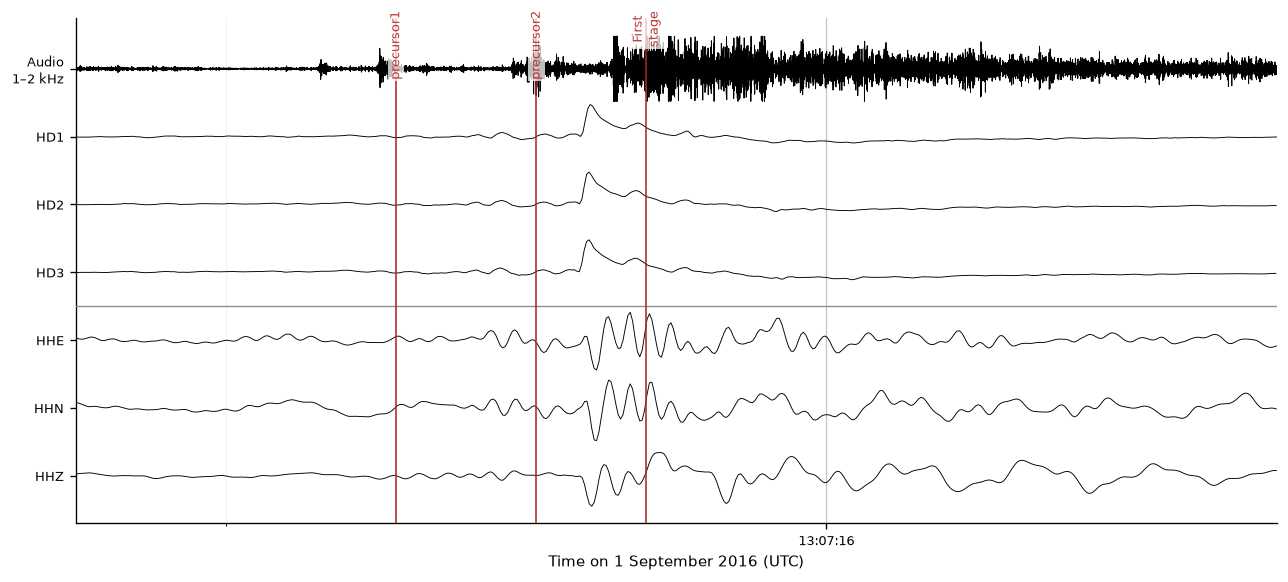

Reducing YT.SYNC..AUD by 3.7550 s
Reducing FL.BCHH.00.HD1 by 3.9254 s
Reducing FL.BCHH.00.HD2 by 3.8392 s
Reducing FL.BCHH.00.HD3 by 3.8515 s
Reducing FL.BCHH.00.HHE by 3.8707 s
Reducing FL.BCHH.00.HHN by 3.8707 s
Reducing FL.BCHH.00.HHZ by 3.8707 s
Plotting fig03_bchh_first_stage_closeup_with_audio_reduced_zp_true: ZEROPHASE=True, REDUCE_TIME=True, acoustic speed=366.8 m/s


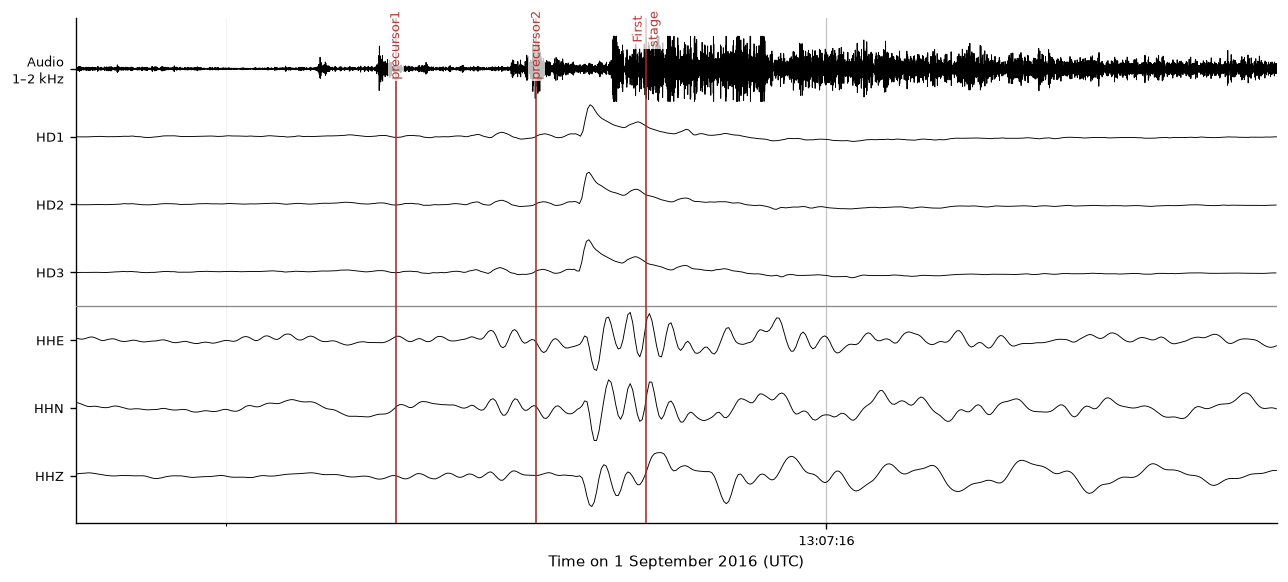

Reducing YT.SYNC..AUD by 3.7550 s
Reducing FL.BCHH.00.HD1 by 3.9254 s
Reducing FL.BCHH.00.HD2 by 3.8392 s
Reducing FL.BCHH.00.HD3 by 3.8515 s
Reducing FL.BCHH.00.HHE by 3.8707 s
Reducing FL.BCHH.00.HHN by 3.8707 s
Reducing FL.BCHH.00.HHZ by 3.8707 s
Plotting fig03_bchh_first_stage_closeup_with_audio_reduced_zp_false: ZEROPHASE=False, REDUCE_TIME=True, acoustic speed=366.8 m/s


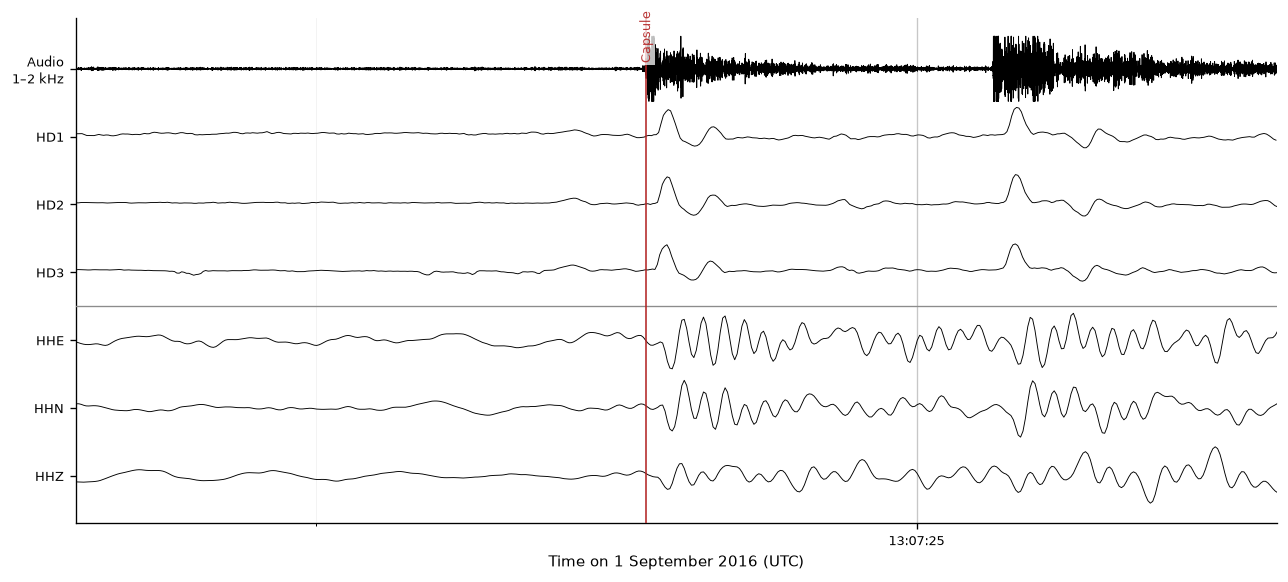

Reducing YT.SYNC..AUD by 3.7550 s
Reducing FL.BCHH.00.HD1 by 3.9254 s
Reducing FL.BCHH.00.HD2 by 3.8392 s
Reducing FL.BCHH.00.HD3 by 3.8515 s
Reducing FL.BCHH.00.HHE by 3.8707 s
Reducing FL.BCHH.00.HHN by 3.8707 s
Reducing FL.BCHH.00.HHZ by 3.8707 s
Plotting fig03_bchh_first_stage_closeup_with_audio_reduced_zp_true: ZEROPHASE=True, REDUCE_TIME=True, acoustic speed=366.8 m/s


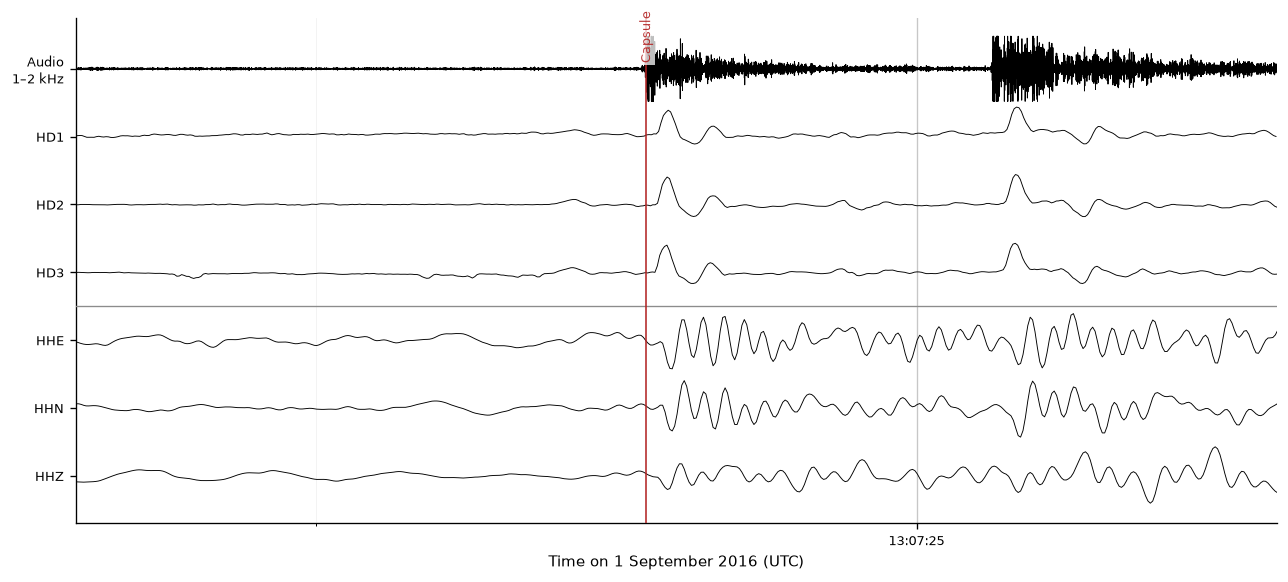

In [25]:

REDUCE_TIME = True

zoom_start = EXPLOSION_TIME - 2
zoom_end = EXPLOSION_TIME + 28
# effective acoustic speed is 353.8 m/s

# If the audio trace start time has already been synchronized to source/video time,
# keep this at 0. If the audio is still in observed time, set the needed shift here.

# best numbers for acoustic arrivals
audio_delay_s = 3.89
time_tweak = 0.12 #+ 0.15
audio_tweak = 0.0
# corresponds to 363.7 m/s
# but we should adjust the centaur data and audio by these amounts - and then do the additional processing

# best numbers for big blast arrivals
'''
audio_delay_s = 3.89
time_tweak = 0.29
audio_tweak = 0.065
'''
# corresponds to 381.3 m/s


# best numbers for acoustic arrivals
audio_delay_s = 3.955
time_tweak = 0.2
audio_tweak = 0.0
# corresponds to 
# but we should adjust the centaur data and audio by these amounts - and then do the additional processing

# best numbers for big blast arrivals
'''
audio_delay_s = 3.89
time_tweak = 0.29
audio_tweak = 0.065
'''
# corresponds to 

SOURCE_EVENTS['First\nstage'] = UTCDateTime(2016, 9, 1, 13, 7, 15.7)
SOURCE_EVENTS['Capsule'] = UTCDateTime(2016, 9, 1, 13, 7, 24.55) 

seismic_distance = SENSOR_DISTANCES_M["HHZ"]
EFFECTIVE_ACOUSTIC_SPEED_MPS = ACOUSTIC_SPEED_MPS# + WIND_SPEED_MPS

print(f"Acoustic speed = {ACOUSTIC_SPEED_MPS:.1f} m/s")
print(f"Wind speed = {WIND_SPEED_MPS:.1f} m/s")
print(f"Effective acoustic speed = {EFFECTIVE_ACOUSTIC_SPEED_MPS:.1f} m/s")
print(f"Adding a time adjustment of {time_tweak:.2f} s to align Centaur data to SpaceX video event time markers")

speed_to_use = seismic_distance / (seismic_distance / EFFECTIVE_ACOUSTIC_SPEED_MPS - time_tweak)
audio_delay_to_use = audio_delay_s - time_tweak + audio_tweak

print(f"Adjusted speed from {EFFECTIVE_ACOUSTIC_SPEED_MPS:.1f} m/s to {speed_to_use:.1f} m/s to match the time adjustment")
print(f"Audio is delayed by {audio_delay_to_use:.2f} s")

zoom_filter_settings = {
    "infra_freqmin": 0.05,
    "infra_freqmax": 120.0,
    "seis_freqmin": 0.05,
    "seis_freqmax": 120.0,
    "audio_freqmin": 1000.0,
    "audio_freqmax": 2000.0,
    "corners": 4,
    "pad_seconds": 10.0,
}

zoom_plot_settings = {
    "show_source_times": True,
    "show_event_windows": False,
    "normalize_by_group": False,
    "clip": 1.2,
    "trace_gain": 0.4,
}

zoom_results = []
zerophase_values_to_run = ZEROPHASE_RUNS if RUN_ZEROPHASE_COMPARISON else [ZEROPHASE]

for zp in zerophase_values_to_run:
    zoom_results.append(
        make_zoom_variant(
            stcentaur=st_ordered,
            staudio=st_audio_raw,
            output_dir=OUTDIR,
            zerophase=zp,
            reduce_time=REDUCE_TIME,
            window_start=zoom_start,
            window_end=zoom_end,
            source_events=SOURCE_EVENTS,
            sensor_distances_m=SENSOR_DISTANCES_M,
            acoustic_speed_mps=speed_to_use,
            audio_delay_s=audio_delay_to_use,
            event_window_s=VIDEO_PICK_UNCERTAINTY_S,
            outfile_stem="fig03_bchh_20s_zoom_with_audio",
            show=True,
            zoom_filter_settings=zoom_filter_settings,
            plot_settings=zoom_plot_settings,
        )
    )

# Backward-compatible names for later exploratory cells.
st_zoom_plot = zoom_results[0]["stream"]
outfile = zoom_results[0]["outfile"]

# Optional tighter view around the first-stage event for every zerophase variant.
closeup_results = []

for result in zoom_results:
    closeup_results.append(
        make_zoom_variant(
            stcentaur=st_ordered,
            staudio=st_audio_raw,
            output_dir=OUTDIR,
            zerophase=result["zerophase"],
            reduce_time=result["reduce_time"],
            window_start=EXPLOSION_TIME - 1,
            window_end=EXPLOSION_TIME + 1,
            source_events=SOURCE_EVENTS,
            sensor_distances_m=SENSOR_DISTANCES_M,
            acoustic_speed_mps=speed_to_use,
            audio_delay_s=audio_delay_to_use,
            event_window_s=VIDEO_PICK_UNCERTAINTY_S,
            outfile_stem="fig03_bchh_first_stage_closeup_with_audio",
            show=True,
            zoom_filter_settings=zoom_filter_settings,
            plot_settings=zoom_plot_settings,
        )
    )

for result in zoom_results:
    closeup_results.append(
        make_zoom_variant(
            stcentaur=st_ordered,
            staudio=st_audio_raw,
            output_dir=OUTDIR,
            zerophase=result["zerophase"],
            reduce_time=result["reduce_time"],
            window_start=precursor1 - 1.75,
            window_end=precursor1 + 0.25,
            source_events=SOURCE_EVENTS,
            sensor_distances_m=SENSOR_DISTANCES_M,
            acoustic_speed_mps=speed_to_use,
            audio_delay_s=audio_delay_to_use,
            event_window_s=VIDEO_PICK_UNCERTAINTY_S,
            outfile_stem="fig03_bchh_first_stage_closeup_with_audio",
            show=True,
            zoom_filter_settings=zoom_filter_settings,
            plot_settings=zoom_plot_settings,
        )
    )

for result in zoom_results:
    closeup_results.append(
        make_zoom_variant(
            stcentaur=st_ordered,
            staudio=st_audio_raw,
            output_dir=OUTDIR,
            zerophase=result["zerophase"],
            reduce_time=result["reduce_time"],
            window_start=FIRST_STAGE - 1,
            window_end=FIRST_STAGE + 1,
            source_events=SOURCE_EVENTS,
            sensor_distances_m=SENSOR_DISTANCES_M,
            acoustic_speed_mps=speed_to_use,
            audio_delay_s=audio_delay_to_use,
            event_window_s=VIDEO_PICK_UNCERTAINTY_S,
            outfile_stem="fig03_bchh_first_stage_closeup_with_audio",
            show=True,
            zoom_filter_settings=zoom_filter_settings,
            plot_settings=zoom_plot_settings,
        )
    )


for result in zoom_results:
    closeup_results.append(
        make_zoom_variant(
            stcentaur=st_ordered,
            staudio=st_audio_raw,
            output_dir=OUTDIR,
            zerophase=result["zerophase"],
            reduce_time=result["reduce_time"],
            window_start=CAPSULE - 1,
            window_end=CAPSULE + 1,
            source_events=SOURCE_EVENTS,
            sensor_distances_m=SENSOR_DISTANCES_M,
            acoustic_speed_mps=speed_to_use,
            audio_delay_s=audio_delay_to_use,
            event_window_s=VIDEO_PICK_UNCERTAINTY_S,
            outfile_stem="fig03_bchh_first_stage_closeup_with_audio",
            show=True,
            zoom_filter_settings=zoom_filter_settings,
            plot_settings=zoom_plot_settings,
        )
    )




## 13. PSD

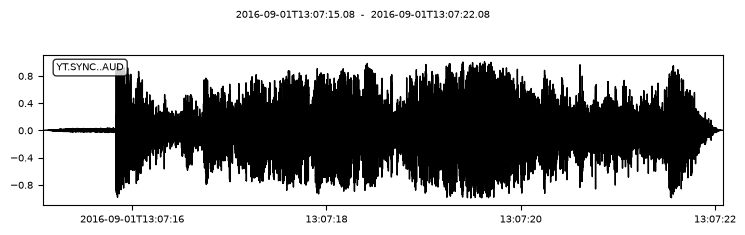

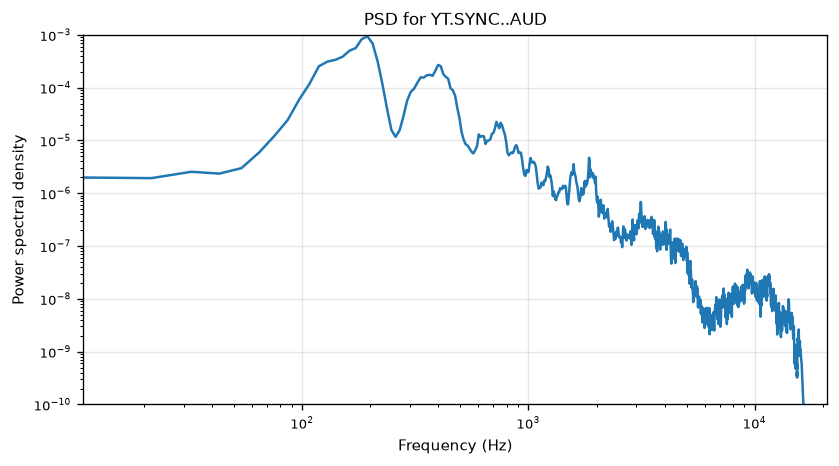

In [26]:
from scipy.signal import welch
import matplotlib.pyplot as plt
def psd_plot(st, xlims=None, ylims=None, nyquist_percentage=0.95, plot_trace=False):
    for tr in st:
        tr = tr.copy()
        tr.detrend("demean")
        tr.taper(max_percentage=0.05)
        if plot_trace:
            tr.plot()

        fs = tr.stats.sampling_rate
        highest_freq_to_plot = 0.5 * fs * nyquist_percentage
        x = tr.data.astype(float)

        f, Pxx = welch(
            x,
            fs=fs,
            nperseg=min(4096, len(x)),
            noverlap=None,
            scaling="density"
        )

        plt.figure(figsize=(8, 4))
        plt.loglog(f, Pxx)
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("Power spectral density")
        plt.title(f"PSD for {tr.id}")
        if xlims is None:
            xlims = (f[1], highest_freq_to_plot)
        xlims = (max(xlims[0], f[1]), min(xlims[1], highest_freq_to_plot))
        plt.xlim(xlims)
        if ylims is not None:
            plt.ylim(ylims)
        plt.grid(True, alpha=0.3)
        plt.show()

st_spec = st_audio_raw.copy().trim(starttime=EXPLOSION_TIME+3, endtime=EXPLOSION_TIME+10)
psd_plot(st_spec, ylims=(1e-10, 1e-3), plot_trace=True)#, xlims=(1, 10000))